# DATATHON 2026 — Question 3 Sales Forecasting Pipeline

## Business objective
Forecast daily `Revenue` and `COGS` for the required test period while respecting the competition constraints

## 0. Configuration and imports

All project-level controls live here. This is intentionally centralized so the notebook behaves like a production pipeline rather than disconnected exploratory cells.

In [23]:
# ============================================================
# 0. CONFIGURATION
# ============================================================

from pathlib import Path
import os
import sys
import json
import math
import random
import re
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# ----------------------------
# Reproducibility
# ----------------------------
RANDOM_SEED = 67
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ----------------------------
# Runtime controls
# ----------------------------
RUN_MODE = "quick"
RUN_BACKTEST = True
RUN_TUNING = False
USE_SUPPORT_TABLES = True
USE_OPTIONAL_GBDT = True
FORCE_REBUILD_CACHE = False
CLIP_FORECASTS = True

# ----------------------------
# Forecast settings
# ----------------------------
TARGETS = ["Revenue", "COGS"]
PRIMARY_TARGET = "Revenue"
TEST_START = "2023-01-01"
TEST_END = "2024-07-01"

# Longer lags for long-term (> 1 year) forecast horizon.
TARGET_LAGS = [1, 2, 3, 7, 14, 28, 56, 91, 182, 365, 730]
TARGET_ROLL_WINDOWS = [7, 14, 28, 56, 91, 182, 365]
AUX_LAGS = [365, 730]
AUX_ROLL_WINDOWS = [28, 91]

if RUN_MODE == "quick":
    N_CV_FOLDS = 2
    CV_HORIZON_DAYS = 180
    MAX_AUX_RAW_FEATURES = 45
    MAX_TRAIN_ROWS_FOR_TUNING = 1800
else:
    N_CV_FOLDS = 3
    CV_HORIZON_DAYS = None
    MAX_AUX_RAW_FEATURES = 120
    MAX_TRAIN_ROWS_FOR_TUNING = None

# ----------------------------
# Path discovery
# ----------------------------
BASE_DIR = Path.cwd()
CANDIDATE_DATA_DIRS = [BASE_DIR / "data", BASE_DIR, Path("/mnt/data")]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if (p / "sales.csv").exists()), BASE_DIR)
OUTPUT_DIR = BASE_DIR / "outputs"
CACHE_DIR = OUTPUT_DIR / "cache"
MODEL_DIR = OUTPUT_DIR / "models"
for p in [OUTPUT_DIR, CACHE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"RUN_MODE={RUN_MODE}")
print(f"Target columns: {TARGETS}; primary leaderboard target: {PRIMARY_TARGET}")

RUN_MODE=quick
Target columns: ['Revenue', 'COGS']; primary leaderboard target: Revenue


## 1. Utility functions

These helpers make every later section repeatable: same file loading behavior, same metrics, same plotting conventions, same leakage checks.

In [24]:
# ============================================================
# 1. UTILITY FUNCTIONS
# ============================================================

DATE_COLS_BY_FILE = {
    "sales.csv": ["Date"],
    "sales_test.csv": ["Date"],
    "sample_submission.csv": ["Date"],
    "orders.csv": ["order_date"],
    "shipments.csv": ["ship_date", "delivery_date"],
    "returns.csv": ["return_date"],
    "reviews.csv": ["review_date"],
    "web_traffic.csv": ["date"],
    "inventory.csv": ["snapshot_date"],
    "customers.csv": ["signup_date"],
    "promotions.csv": ["start_date", "end_date"],
}


def file_path(name: str) -> Path:
    return DATA_DIR / name


def exists(name: str) -> bool:
    return file_path(name).exists()


def read_csv(name: str, usecols=None, parse_dates=None, dtype=None) -> pd.DataFrame:
    """Read a provided CSV. No external data is used anywhere in this notebook."""
    path = file_path(name)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    if parse_dates is None:
        parse_dates = DATE_COLS_BY_FILE.get(name, None)
    return pd.read_csv(path, usecols=usecols, parse_dates=parse_dates, dtype=dtype, low_memory=False)


def safe_read_csv(name: str, usecols=None, parse_dates=None, dtype=None) -> pd.DataFrame | None:
    if not exists(name):
        print(f"[skip] {name} not found")
        return None
    return read_csv(name, usecols=usecols, parse_dates=parse_dates, dtype=dtype)


def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.select_dtypes(include=["int64", "float64"]).columns:
        if pd.api.types.is_integer_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        else:
            out[col] = pd.to_numeric(out[col], downcast="float")
    return out


def metric_dict(y_true, y_pred, prefix="") -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {
        f"{prefix}mae": mean_absolute_error(y_true, y_pred),
        f"{prefix}rmse": float(np.sqrt(mse)),
        f"{prefix}r2": r2_score(y_true, y_pred),
    }


def summarize_frame(df: pd.DataFrame, name: str, date_col: str | None = None) -> pd.DataFrame:
    info = {
        "file": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
    }
    if date_col and date_col in df.columns:
        info["min_date"] = df[date_col].min()
        info["max_date"] = df[date_col].max()
        info["duplicate_dates"] = int(df[date_col].duplicated().sum())
    return pd.DataFrame([info])


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False)
    return path


def save_parquet_or_pickle(df: pd.DataFrame, stem: str) -> Path:
    parquet_path = CACHE_DIR / f"{stem}.parquet"
    pickle_path = CACHE_DIR / f"{stem}.pkl"
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception:
        df.to_pickle(pickle_path)
        return pickle_path


def load_parquet_or_pickle(stem: str) -> pd.DataFrame | None:
    parquet_path = CACHE_DIR / f"{stem}.parquet"
    pickle_path = CACHE_DIR / f"{stem}.pkl"
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)
    return None


def plot_barh(series: pd.Series, title: str, xlabel: str, top_n: int = 25):
    s = series.dropna().sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(s))))
    ax.barh(s.index.astype(str), s.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_line(df: pd.DataFrame, x: str, y_cols: list[str], title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in y_cols:
        if col in df.columns:
            ax.plot(df[x], df[col], label=col, linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


def assert_no_leakage_columns(feature_cols: list[str]):
    """Fail only on truly unshifted leakage columns.

    Auxiliary operational columns are intentionally created first with a *_raw_* prefix,
    then converted into forecast-safe historical features such as:
      - *_lag_365
      - *_lag_730
      - *_lag365_rollmean_28
      - *_lag730_rollmean_91
    """
    forbidden_exact = set(TARGETS + ["Date"])
    bad_exact = [c for c in feature_cols if c in forbidden_exact]
    if bad_exact:
        raise ValueError(f"Leakage risk: raw target/date columns present in features: {bad_exact}")

    operational_prefixes = (
        "orders_raw_", "items_raw_", "payments_raw_", "returns_raw_",
        "reviews_raw_", "shipments_raw_", "traffic_raw_", "inventory_raw_"
    )

    # Safe operational features must contain a historical lag marker.
    safe_lag_pattern = re.compile(r"(_lag_\d+|_lag\d+_)")

    bad_unshifted = [
        c for c in feature_cols
        if c.startswith(operational_prefixes) and safe_lag_pattern.search(c) is None
    ]
    if bad_unshifted:
        raise ValueError(
            "Leakage risk: same-day/unshifted operational features present. "
            f"Examples: {bad_unshifted[:10]}"
        )

    print(f"Leakage guard passed for {len(feature_cols)} model features.")

## 2. Load competition target and submission/test frame

`QUESTION 3` asks for a submission with `Date, Revenue, COGS`. The notebook forecasts both columns, but treats `Revenue` as the primary business/leaderboard target. If `sales_test.csv` or `sample_submission.csv` is present, the notebook uses its `Date` order. If neither exists, it creates the required date range from 2023-01-01 to 2024-07-01.

In [25]:
# ============================================================
# 2. LOAD CORE TARGET AND TEST/SUBMISSION FRAME
# ============================================================

sales = read_csv("sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
for col in TARGETS:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

# Submission frame discipline: preserve sample_submission order when available.
if exists("sample_submission.csv"):
    submission_frame = read_csv("sample_submission.csv", parse_dates=["Date"])
    test_frame = submission_frame[["Date"]].copy()
    print("Using sample_submission.csv order for final output.")
elif exists("sales_test.csv"):
    tmp_test = read_csv("sales_test.csv", parse_dates=["Date"])
    # Critical: never use test Revenue/COGS values as features, even if present.
    test_frame = tmp_test[["Date"]].copy()
    print("Using Date column from sales_test.csv; target columns are ignored to avoid leakage.")
else:
    test_frame = pd.DataFrame({"Date": pd.date_range(TEST_START, TEST_END, freq="D")})
    print(f"No sample_submission.csv or sales_test.csv found. Created test frame: {TEST_START} to {TEST_END}.")

sales_summary = summarize_frame(sales, "sales.csv", "Date")
test_summary = summarize_frame(test_frame, "test_frame", "Date")
display(pd.concat([sales_summary, test_summary], ignore_index=True))

display(sales.head())
display(sales.tail())
print(f"Train period: {sales['Date'].min().date()} to {sales['Date'].max().date()} | Test dates: {len(test_frame)}")

Using sample_submission.csv order for final output.


,file,rows,columns,missing_cells,min_date,max_date,duplicate_dates
0,sales.csv,3833,3,0,2012-07-04,2022-12-31,0
1,test_frame,548,1,0,2023-01-01,2024-07-01,0


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


Train period: 2012-07-04 to 2022-12-31 | Test dates: 548


## 3. Data audit across all provided tables

This block checks schema, date coverage, row counts, duplicates, and missingness. It is intentionally light enough to rerun often.

In [26]:
# ============================================================
# 3. DATA AUDIT
# ============================================================

provided_files = [
    "sales.csv", "orders.csv", "order_items.csv", "products.csv", "promotions.csv",
    "web_traffic.csv", "inventory.csv", "returns.csv", "reviews.csv", "shipments.csv",
    "payments.csv", "customers.csv", "geography.csv", "sales_test.csv", "sample_submission.csv"
]

audit_rows = []
for name in provided_files:
    if not exists(name):
        continue
    path = file_path(name)
    # Read only a sample for schema and missingness estimate; full heavy tables are summarized in feature sections.
    sample = pd.read_csv(path, nrows=5000, low_memory=False)
    date_cols = DATE_COLS_BY_FILE.get(name, [])
    row = {
        "file": name,
        "size_mb": round(path.stat().st_size / 1024**2, 2),
        "sample_rows_read": len(sample),
        "n_columns": sample.shape[1],
        "columns": ", ".join(sample.columns[:12]) + (" ..." if sample.shape[1] > 12 else ""),
        "sample_missing_pct": round(100 * sample.isna().mean().mean(), 3),
    }
    for dc in date_cols[:2]:
        if dc in sample.columns:
            parsed = pd.to_datetime(sample[dc], errors="coerce")
            row[f"sample_{dc}_min"] = parsed.min()
            row[f"sample_{dc}_max"] = parsed.max()
    audit_rows.append(row)

audit = pd.DataFrame(audit_rows)
display(audit)
save_table(audit, "data_audit_summary.csv")

# Core target checks
assert sales["Date"].is_monotonic_increasing, "sales.csv must be sorted by Date."
assert sales["Date"].duplicated().sum() == 0, "Duplicate dates found in sales.csv."
assert sales[TARGETS].isna().sum().sum() == 0, "Missing Revenue/COGS found in training target."

,file,size_mb,sample_rows_read,n_columns,columns,sample_missing_pct,sample_Date_min,sample_Date_max,sample_order_date_min,sample_order_date_max,sample_start_date_min,sample_start_date_max,sample_end_date_min,sample_end_date_max,sample_date_min,sample_date_max,sample_snapshot_date_min,sample_snapshot_date_max,sample_return_date_min,sample_return_date_max,sample_review_date_min,sample_review_date_max,sample_ship_date_min,sample_ship_date_max,sample_delivery_date_min,sample_delivery_date_max,sample_signup_date_min,sample_signup_date_max
0,sales.csv,0.12,3833,3,"Date, Revenue, COGS",0.000,2012-07-04,2022-12-31,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,orders.csv,43.83,5000,8,"order_id, order_date, customer_id, zip, order_...",0.000,NaT,NaT,2012-07-04,2012-08-02,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,order_items.csv,22.83,5000,7,"order_id, product_id, quantity, unit_price, di...",28.571,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,products.csv,0.19,2412,8,"product_id, product_name, category, segment, s...",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,promotions.csv,0.00,50,10,"promo_id, promo_name, promo_type, discount_val...",8.000,NaT,NaT,NaT,NaT,2013-01-31,2022-11-18,2013-03-01,2022-12-31,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
5,web_traffic.csv,0.20,3652,7,"date, sessions, unique_visitors, page_views, b...",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2013-01-01,2022-12-31,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
6,inventory.csv,5.41,5000,17,"snapshot_date, product_id, stock_on_hand, unit...",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2012-07-31,2022-12-31,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7,returns.csv,2.18,5000,7,"return_id, order_id, product_id, return_date, ...",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2012-07-11,2013-08-15,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
8,reviews.csv,6.48,5000,7,"review_id, order_id, product_id, customer_id, ...",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2012-07-10,2013-01-20,NaT,NaT,NaT,NaT,NaT,NaT
9,shipments.csv,18.84,5000,4,"order_id, ship_date, delivery_date, shipping_fee",0.000,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2012-07-04,2012-08-07,2012-07-06,2012-08-14,NaT,NaT


## 4. Descriptive EDA: target, margin, and calendar seasonality

These charts support both model design and the business report. The goal is not only to inspect historical values, but to identify the seasonality and volatility that the forecasting features must learn.

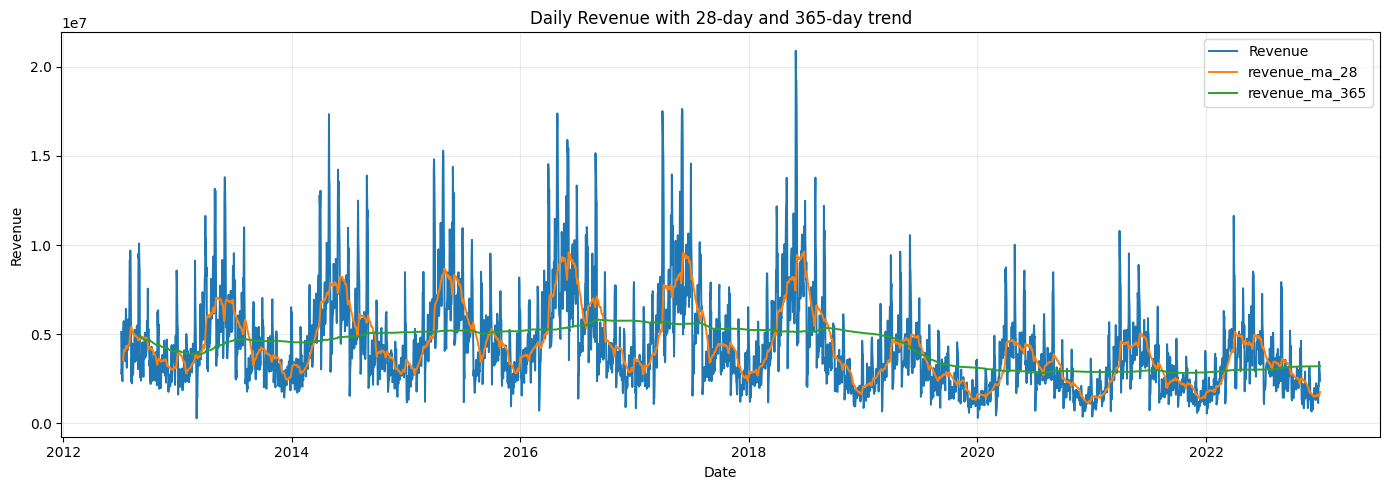

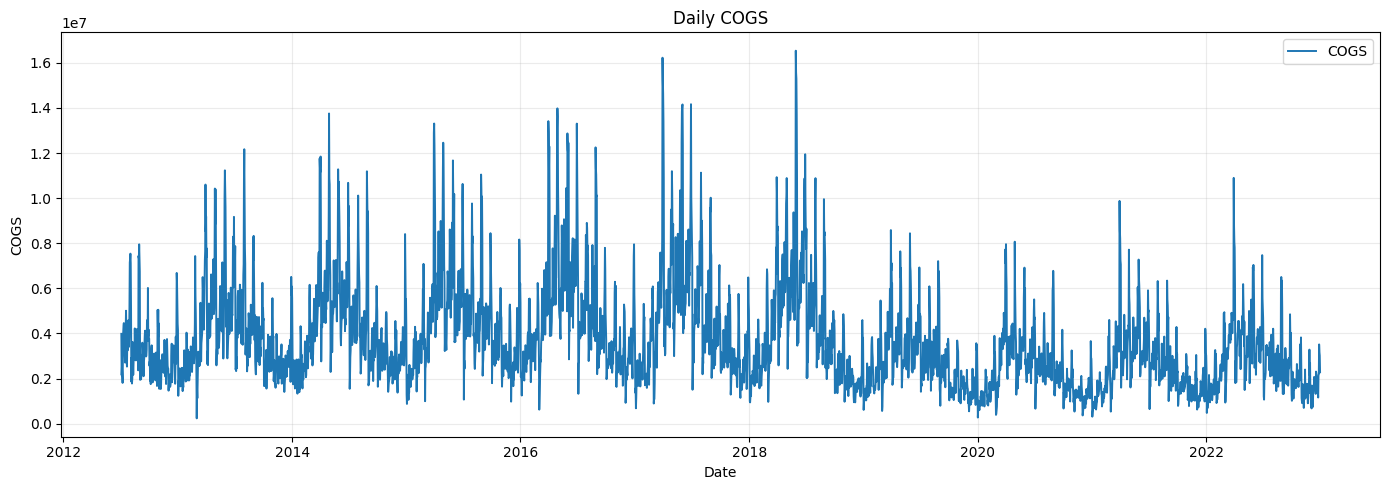

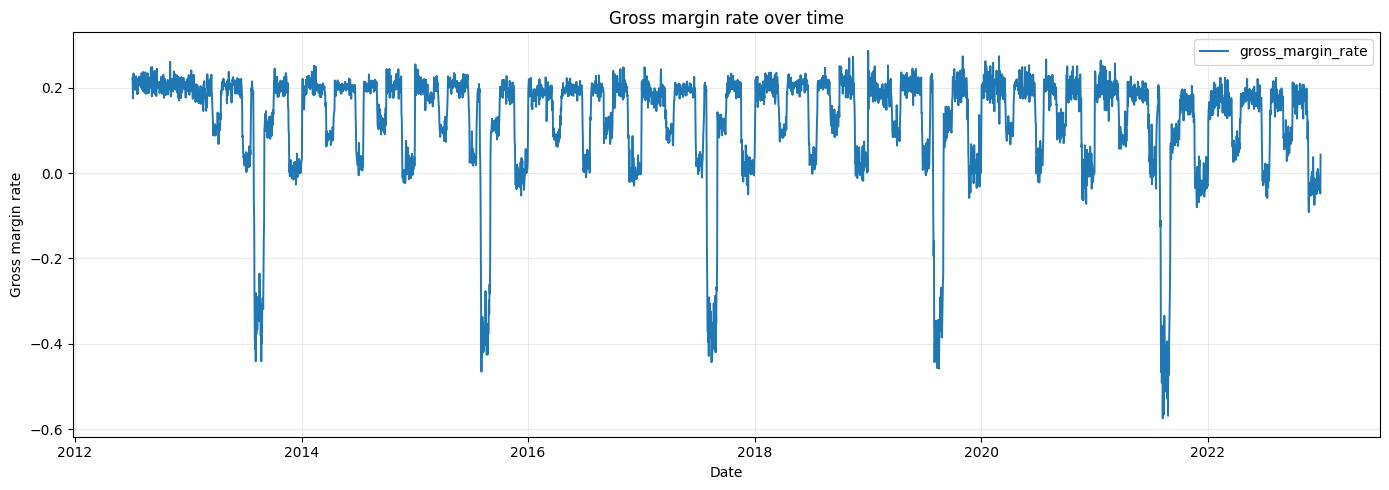

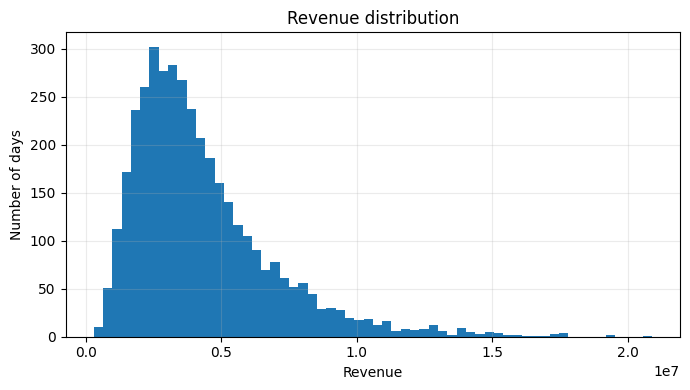

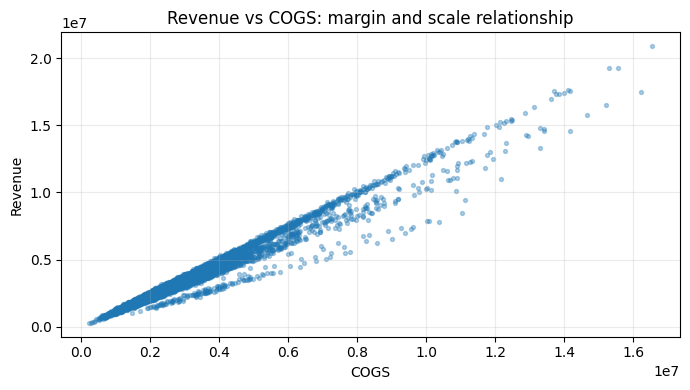

In [27]:
# ============================================================
# 4. DESCRIPTIVE EDA
# ============================================================

eda = sales.copy()
eda["gross_margin"] = eda["Revenue"] - eda["COGS"]
eda["gross_margin_rate"] = np.where(eda["Revenue"] > 0, eda["gross_margin"] / eda["Revenue"], np.nan)
eda["revenue_ma_28"] = eda["Revenue"].rolling(28, min_periods=7).mean()
eda["revenue_ma_365"] = eda["Revenue"].rolling(365, min_periods=60).mean()

plot_line(eda, "Date", ["Revenue", "revenue_ma_28", "revenue_ma_365"], "Daily Revenue with 28-day and 365-day trend", "Revenue")
plot_line(eda, "Date", ["COGS"], "Daily COGS", "COGS")
plot_line(eda, "Date", ["gross_margin_rate"], "Gross margin rate over time", "Gross margin rate")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(eda["Revenue"], bins=60)
ax.set_title("Revenue distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Number of days")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(eda["COGS"], eda["Revenue"], s=8, alpha=0.35)
ax.set_title("Revenue vs COGS: margin and scale relationship")
ax.set_xlabel("COGS")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

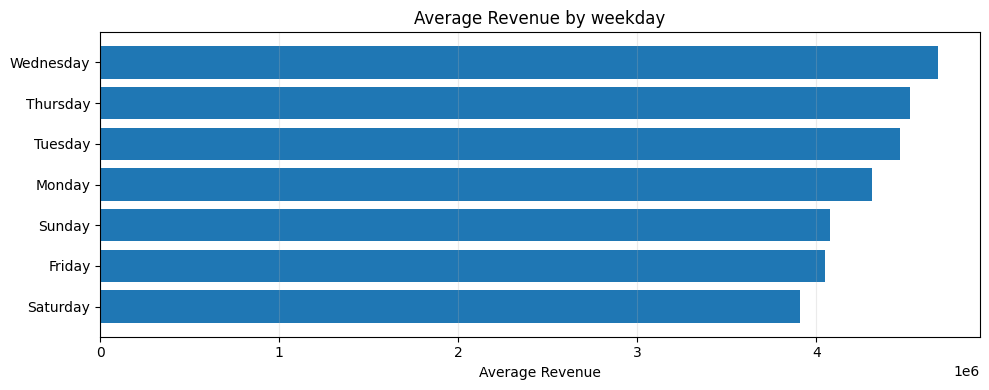

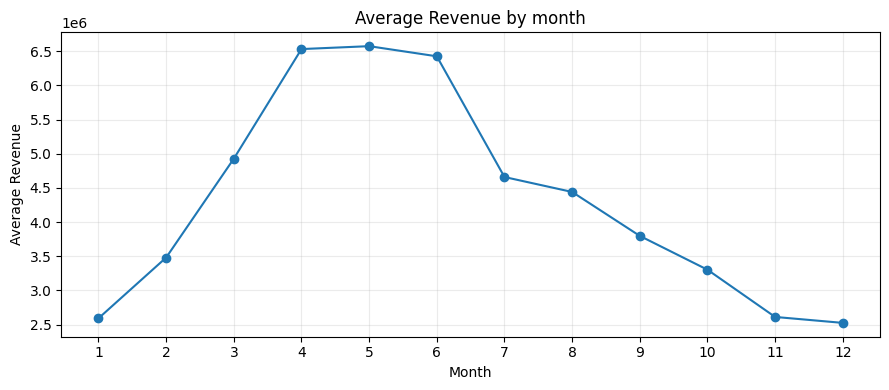

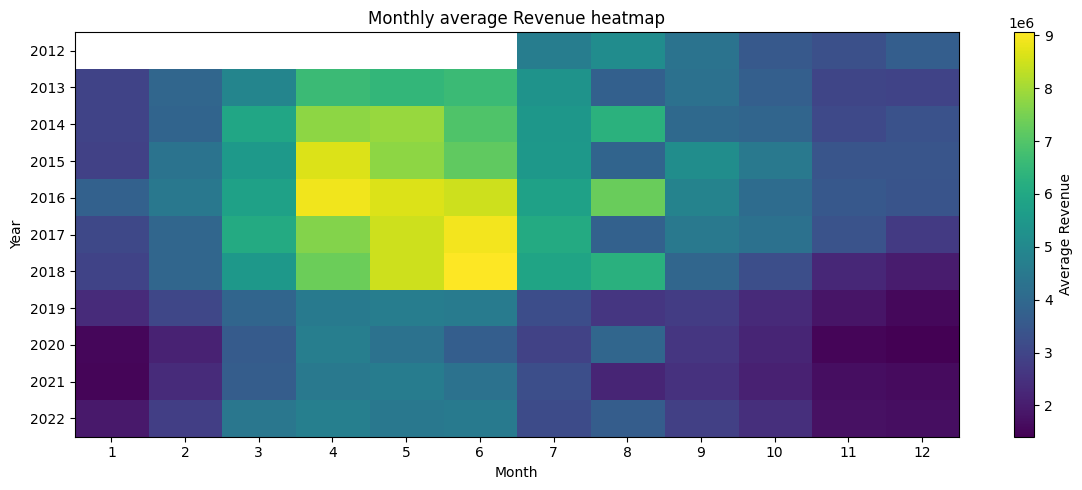

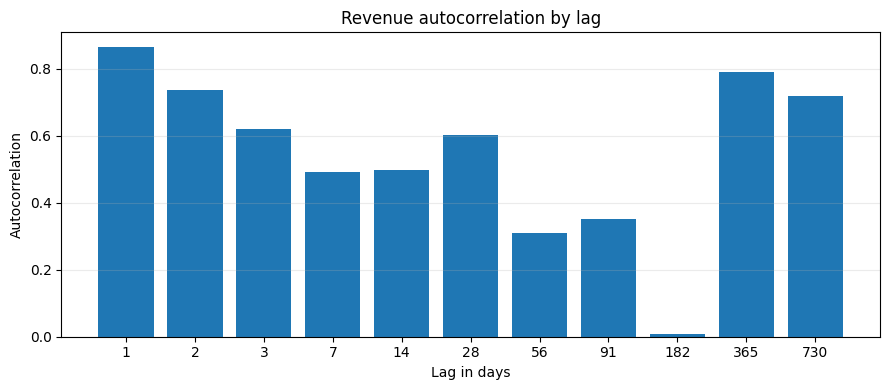

In [28]:
# Calendar seasonality charts
season = sales.copy()
season["year"] = season["Date"].dt.year
season["month"] = season["Date"].dt.month
season["weekday"] = season["Date"].dt.day_name()
season["dayofweek"] = season["Date"].dt.dayofweek
season["weekofyear"] = season["Date"].dt.isocalendar().week.astype(int)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_rev = season.groupby("weekday")["Revenue"].mean().reindex(weekday_order)
plot_barh(weekday_rev, "Average Revenue by weekday", "Average Revenue", top_n=7)

month_rev = season.groupby("month")["Revenue"].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(month_rev.index, month_rev.values, marker="o")
ax.set_title("Average Revenue by month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Revenue")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

monthly_heat = season.pivot_table(index="year", columns="month", values="Revenue", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(monthly_heat.values, aspect="auto")
ax.set_title("Monthly average Revenue heatmap")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticks(np.arange(12))
ax.set_xticklabels(range(1, 13))
ax.set_yticks(np.arange(len(monthly_heat.index)))
ax.set_yticklabels(monthly_heat.index)
fig.colorbar(im, ax=ax, label="Average Revenue")
plt.tight_layout()
plt.show()

# Autocorrelation: confirms why 7-day, monthly-ish, yearly lags matter.
autocorr_lags = [1, 2, 3, 7, 14, 28, 56, 91, 182, 365, 730]
autocorr = pd.Series({lag: sales["Revenue"].autocorr(lag=lag) for lag in autocorr_lags})
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(autocorr.index.astype(str), autocorr.values)
ax.set_title("Revenue autocorrelation by lag")
ax.set_xlabel("Lag in days")
ax.set_ylabel("Autocorrelation")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Diagnostic EDA from supporting tables

This section translates ecommerce operations into safe forecasting signals. Same-day orders, payments, returns, reviews, shipments, traffic, and inventory can be target leakage if used directly for the same date. The pipeline therefore converts them into **seasonal lagged historical signals** by default, which are known before the forecast period starts. Promotions are different: a promo calendar is known before the forecast date, so same-day promotion indicators are allowed.

In [29]:
# ============================================================
# 5. SUPPORTING TABLE AGGREGATION
# ============================================================

def all_model_dates(sales_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    all_dates = pd.date_range(sales_df["Date"].min(), test_df["Date"].max(), freq="D")
    return pd.DataFrame({"Date": all_dates})


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = out["Date"]
    out["year"] = dt.dt.year
    out["month"] = dt.dt.month
    out["day"] = dt.dt.day
    out["dayofweek"] = dt.dt.dayofweek
    out["dayofyear"] = dt.dt.dayofyear
    out["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    out["quarter"] = dt.dt.quarter
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["is_month_start"] = dt.dt.is_month_start.astype(int)
    out["is_month_end"] = dt.dt.is_month_end.astype(int)
    out["is_quarter_start"] = dt.dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)
    out["days_since_start"] = (dt - dt.min()).dt.days
    # Cyclical encoding helps linear and tree models learn calendar seasonality smoothly.
    for period, col in [(7, "dayofweek"), (12, "month"), (365.25, "dayofyear")]:
        out[f"{col}_sin"] = np.sin(2 * np.pi * out[col] / period)
        out[f"{col}_cos"] = np.cos(2 * np.pi * out[col] / period)
    return out


def build_promotion_features(all_dates_df: pd.DataFrame) -> pd.DataFrame:
    promo_daily = all_dates_df.copy()
    promo_daily["promo_active_count"] = 0
    promo_daily["promo_discount_max"] = 0.0
    promo_daily["promo_discount_sum"] = 0.0
    promo_daily["promo_min_order_max"] = 0.0
    promo_daily["promo_stackable_count"] = 0

    if not exists("promotions.csv"):
        return promo_daily

    promos = read_csv("promotions.csv", parse_dates=["start_date", "end_date"])
    promos["discount_value"] = pd.to_numeric(promos["discount_value"], errors="coerce").fillna(0)
    promos["min_order_value"] = pd.to_numeric(promos["min_order_value"], errors="coerce").fillna(0)
    promos["stackable_flag"] = pd.to_numeric(promos["stackable_flag"], errors="coerce").fillna(0)

    # Initialize dynamic one-hot columns for promotion type/channel.
    promo_types = sorted(promos["promo_type"].dropna().astype(str).unique().tolist())
    promo_channels = sorted(promos["promo_channel"].dropna().astype(str).unique().tolist())
    for t in promo_types:
        promo_daily[f"promo_type_{t}_active"] = 0
    for ch in promo_channels:
        promo_daily[f"promo_channel_{ch}_active"] = 0

    for _, row in promos.iterrows():
        mask = (promo_daily["Date"] >= row["start_date"]) & (promo_daily["Date"] <= row["end_date"])
        if not mask.any():
            continue
        promo_daily.loc[mask, "promo_active_count"] += 1
        promo_daily.loc[mask, "promo_discount_sum"] += float(row["discount_value"])
        promo_daily.loc[mask, "promo_discount_max"] = np.maximum(promo_daily.loc[mask, "promo_discount_max"], float(row["discount_value"]))
        promo_daily.loc[mask, "promo_min_order_max"] = np.maximum(promo_daily.loc[mask, "promo_min_order_max"], float(row["min_order_value"]))
        promo_daily.loc[mask, "promo_stackable_count"] += int(row["stackable_flag"])
        if pd.notna(row.get("promo_type")):
            promo_daily.loc[mask, f"promo_type_{row['promo_type']}_active"] += 1
        if pd.notna(row.get("promo_channel")):
            promo_daily.loc[mask, f"promo_channel_{row['promo_channel']}_active"] += 1

    # Known-in-advance timing features.
    active_dates = promo_daily.loc[promo_daily["promo_active_count"] > 0, "Date"]
    if len(active_dates):
        active_set = pd.Series(active_dates.values, index=active_dates.values)
        promo_daily["days_since_promo"] = np.nan
        promo_daily["days_until_promo"] = np.nan
        for i, d in enumerate(promo_daily["Date"]):
            past = active_dates[active_dates <= d]
            future = active_dates[active_dates >= d]
            if len(past):
                promo_daily.loc[i, "days_since_promo"] = (d - past.max()).days
            if len(future):
                promo_daily.loc[i, "days_until_promo"] = (future.min() - d).days
    else:
        promo_daily["days_since_promo"] = np.nan
        promo_daily["days_until_promo"] = np.nan

    return promo_daily


def group_cat_counts(df: pd.DataFrame, date_col: str, cat_col: str, prefix: str) -> pd.DataFrame:
    tmp = df[[date_col, cat_col]].dropna().copy()
    tmp[cat_col] = tmp[cat_col].astype(str)
    counts = pd.crosstab(tmp[date_col], tmp[cat_col])
    counts.columns = [f"{prefix}_{cat_col}_{c}" for c in counts.columns]
    counts = counts.reset_index().rename(columns={date_col: "Date"})
    return counts


def merge_on_date(left: pd.DataFrame, right: pd.DataFrame) -> pd.DataFrame:
    if right is None or right.empty:
        return left
    return left.merge(right, on="Date", how="left")


def build_operational_raw_daily(all_dates_df: pd.DataFrame) -> pd.DataFrame:
    """Build same-day raw operational aggregates. These raw columns are never fed to the model directly."""
    cached = None if FORCE_REBUILD_CACHE else load_parquet_or_pickle("operational_raw_daily")
    if cached is not None:
        print("Loaded cached operational raw daily features.")
        return cached

    daily = all_dates_df.copy()

    if not USE_SUPPORT_TABLES:
        return daily

    # Orders: daily order mix, device mix, source mix. Raw; will be lagged later.
    if exists("orders.csv"):
        orders = read_csv(
            "orders.csv",
            usecols=["order_id", "order_date", "customer_id", "zip", "order_status", "payment_method", "device_type", "order_source"],
            parse_dates=["order_date"],
        )
        orders = orders.rename(columns={"order_date": "Date"})
        orders_agg = orders.groupby("Date").agg(
            orders_raw_order_count=("order_id", "count"),
            orders_raw_unique_customers=("customer_id", "nunique"),
            orders_raw_unique_zip=("zip", "nunique"),
        ).reset_index()
        daily = merge_on_date(daily, orders_agg)
        for cat in ["order_status", "payment_method", "device_type", "order_source"]:
            daily = merge_on_date(daily, group_cat_counts(orders, "Date", cat, "orders_raw"))
    else:
        orders = None

    # Payments: requires order date.
    if exists("payments.csv") and exists("orders.csv"):
        if "orders" not in locals() or orders is None:
            orders = read_csv("orders.csv", usecols=["order_id", "order_date"], parse_dates=["order_date"]).rename(columns={"order_date": "Date"})
        payments = read_csv("payments.csv", usecols=["order_id", "payment_value", "installments", "payment_method"])
        payments = payments.merge(orders[["order_id", "Date"]], on="order_id", how="left")
        payments["payment_value"] = pd.to_numeric(payments["payment_value"], errors="coerce")
        payments["installments"] = pd.to_numeric(payments["installments"], errors="coerce")
        payments_agg = payments.groupby("Date").agg(
            payments_raw_value_sum=("payment_value", "sum"),
            payments_raw_value_mean=("payment_value", "mean"),
            payments_raw_installments_mean=("installments", "mean"),
        ).reset_index()
        daily = merge_on_date(daily, payments_agg)

    # Order items and product mix. Raw; later lagged.
    if exists("order_items.csv") and exists("orders.csv"):
        if "orders" not in locals() or orders is None:
            orders = read_csv("orders.csv", usecols=["order_id", "order_date"], parse_dates=["order_date"]).rename(columns={"order_date": "Date"})
        items = read_csv("order_items.csv", usecols=["order_id", "product_id", "quantity", "unit_price", "discount_amount", "promo_id", "promo_id_2"])
        items = items.merge(orders[["order_id", "Date"]], on="order_id", how="left")
        for col in ["quantity", "unit_price", "discount_amount"]:
            items[col] = pd.to_numeric(items[col], errors="coerce").fillna(0)
        items["gross_item_value"] = items["quantity"] * items["unit_price"]
        items["promo_item_flag"] = items[["promo_id", "promo_id_2"]].notna().any(axis=1).astype(int)
        items_agg = items.groupby("Date").agg(
            items_raw_qty_sum=("quantity", "sum"),
            items_raw_gross_value_sum=("gross_item_value", "sum"),
            items_raw_discount_sum=("discount_amount", "sum"),
            items_raw_unique_products=("product_id", "nunique"),
            items_raw_promo_item_count=("promo_item_flag", "sum"),
        ).reset_index()
        daily = merge_on_date(daily, items_agg)

        if exists("products.csv"):
            products = read_csv("products.csv", usecols=["product_id", "category", "segment", "price", "cogs"])
            items_prod = items.merge(products[["product_id", "category", "segment"]], on="product_id", how="left")
            for cat in ["category", "segment"]:
                pivot = items_prod.pivot_table(index="Date", columns=cat, values="gross_item_value", aggfunc="sum", fill_value=0)
                pivot.columns = [f"items_raw_{cat}_{str(c)}_gross_value" for c in pivot.columns]
                daily = merge_on_date(daily, pivot.reset_index())

    # Web traffic. Raw; later lagged.
    if exists("web_traffic.csv"):
        traffic = read_csv("web_traffic.csv", parse_dates=["date"]).rename(columns={"date": "Date"})
        num_cols = ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]
        for col in num_cols:
            traffic[col] = pd.to_numeric(traffic[col], errors="coerce")
        traffic_agg = traffic.groupby("Date").agg(
            traffic_raw_sessions_sum=("sessions", "sum"),
            traffic_raw_unique_visitors_sum=("unique_visitors", "sum"),
            traffic_raw_page_views_sum=("page_views", "sum"),
            traffic_raw_bounce_rate_mean=("bounce_rate", "mean"),
            traffic_raw_avg_session_duration_mean=("avg_session_duration_sec", "mean"),
        ).reset_index()
        daily = merge_on_date(daily, traffic_agg)
        if "traffic_source" in traffic.columns:
            daily = merge_on_date(daily, group_cat_counts(traffic, "Date", "traffic_source", "traffic_raw"))

    # Returns. Raw; later lagged.
    if exists("returns.csv"):
        returns = read_csv("returns.csv", parse_dates=["return_date"]).rename(columns={"return_date": "Date"})
        for col in ["return_quantity", "refund_amount"]:
            returns[col] = pd.to_numeric(returns[col], errors="coerce")
        returns_agg = returns.groupby("Date").agg(
            returns_raw_count=("return_id", "count"),
            returns_raw_qty_sum=("return_quantity", "sum"),
            returns_raw_refund_sum=("refund_amount", "sum"),
        ).reset_index()
        daily = merge_on_date(daily, returns_agg)
        if "return_reason" in returns.columns:
            daily = merge_on_date(daily, group_cat_counts(returns, "Date", "return_reason", "returns_raw"))

    # Reviews. Raw; later lagged.
    if exists("reviews.csv"):
        reviews = read_csv("reviews.csv", parse_dates=["review_date"]).rename(columns={"review_date": "Date"})
        reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")
        reviews["negative_review_flag"] = (reviews["rating"] <= 2).astype(int)
        reviews_agg = reviews.groupby("Date").agg(
            reviews_raw_count=("review_id", "count"),
            reviews_raw_rating_mean=("rating", "mean"),
            reviews_raw_negative_share=("negative_review_flag", "mean"),
        ).reset_index()
        daily = merge_on_date(daily, reviews_agg)

    # Shipments. Raw; later lagged.
    if exists("shipments.csv"):
        shipments = read_csv("shipments.csv", parse_dates=["ship_date", "delivery_date"])
        shipments["Date"] = shipments["delivery_date"]
        shipments["shipping_fee"] = pd.to_numeric(shipments["shipping_fee"], errors="coerce")
        shipments["delivery_lead_days"] = (shipments["delivery_date"] - shipments["ship_date"]).dt.days
        shipments_agg = shipments.groupby("Date").agg(
            shipments_raw_count=("order_id", "count"),
            shipments_raw_shipping_fee_mean=("shipping_fee", "mean"),
            shipments_raw_delivery_lead_mean=("delivery_lead_days", "mean"),
        ).reset_index()
        daily = merge_on_date(daily, shipments_agg)

    # Inventory monthly snapshots. We forward-fill raw daily inventory position, then lag it later.
    if exists("inventory.csv"):
        inventory = read_csv("inventory.csv", parse_dates=["snapshot_date"]).rename(columns={"snapshot_date": "Date"})
        inv_num = ["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply", "fill_rate", "stockout_flag", "overstock_flag", "reorder_flag", "sell_through_rate"]
        for col in inv_num:
            if col in inventory.columns:
                inventory[col] = pd.to_numeric(inventory[col], errors="coerce")
        agg_spec = {col: "mean" for col in inv_num if col in inventory.columns}
        agg_spec.update({col: "sum" for col in ["stockout_flag", "overstock_flag", "reorder_flag", "stockout_days", "units_received", "units_sold"] if col in inventory.columns})
        inv_agg = inventory.groupby("Date").agg(agg_spec).reset_index()
        inv_agg.columns = ["Date"] + [f"inventory_raw_{c}" for c in inv_agg.columns if c != "Date"]
        daily = merge_on_date(daily, inv_agg)

    daily = daily.sort_values("Date").reset_index(drop=True)
    raw_cols = [c for c in daily.columns if c != "Date"]
    # Historical missing operational counts mean zero observed activity. Future dates remain NaN
    # so lag features do not accidentally treat unknown future operations as real zeros.
    historical_mask = daily["Date"] <= sales["Date"].max()
    daily.loc[historical_mask, raw_cols] = daily.loc[historical_mask, raw_cols].fillna(0)
    daily = downcast_numeric(daily)
    path = save_parquet_or_pickle(daily, "operational_raw_daily")
    return daily


def select_aux_raw_columns(raw_daily: pd.DataFrame, max_cols: int = MAX_AUX_RAW_FEATURES) -> list[str]:
    cols = [c for c in raw_daily.columns if c != "Date"]
    if not cols:
        return []
    variances = raw_daily[cols].var(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0)
    nonzero = variances[variances > 0].sort_values(ascending=False)
    selected = nonzero.head(max_cols).index.tolist()
    return selected


def build_auxiliary_lag_features(raw_daily: pd.DataFrame) -> pd.DataFrame:
    cached = None if FORCE_REBUILD_CACHE else load_parquet_or_pickle("auxiliary_lag_features")
    if cached is not None:
        print("Loaded cached auxiliary lag features.")
        return cached

    selected_cols = select_aux_raw_columns(raw_daily)
    aux = raw_daily[["Date"] + selected_cols].copy().sort_values("Date")
    aux = aux.set_index("Date")
    out = pd.DataFrame(index=aux.index)

    for col in selected_cols:
        s = aux[col].astype(float)
        for lag in AUX_LAGS:
            shifted = s.shift(lag)
            out[f"{col}_lag_{lag}"] = shifted
            for win in AUX_ROLL_WINDOWS:
                out[f"{col}_lag{lag}_rollmean_{win}"] = shifted.rolling(win, min_periods=max(3, win // 4)).mean()

    out = out.reset_index()
    out = downcast_numeric(out)
    path = save_parquet_or_pickle(out, "auxiliary_lag_features")
    return out

all_dates_df = all_model_dates(sales, test_frame)
calendar_features = add_calendar_features(all_dates_df)
promo_features = build_promotion_features(all_dates_df)
raw_operational_daily = build_operational_raw_daily(all_dates_df)
auxiliary_lag_features = build_auxiliary_lag_features(raw_operational_daily)

print("Calendar features:", calendar_features.shape)
print("Promotion features:", promo_features.shape)
print("Raw operational daily features:", raw_operational_daily.shape)
print("Safe auxiliary lag features:", auxiliary_lag_features.shape)

Loaded cached operational raw daily features.
Loaded cached auxiliary lag features.
Calendar features: (4381, 20)
Promotion features: (4381, 15)
Raw operational daily features: (4381, 79)
Safe auxiliary lag features: (4381, 271)


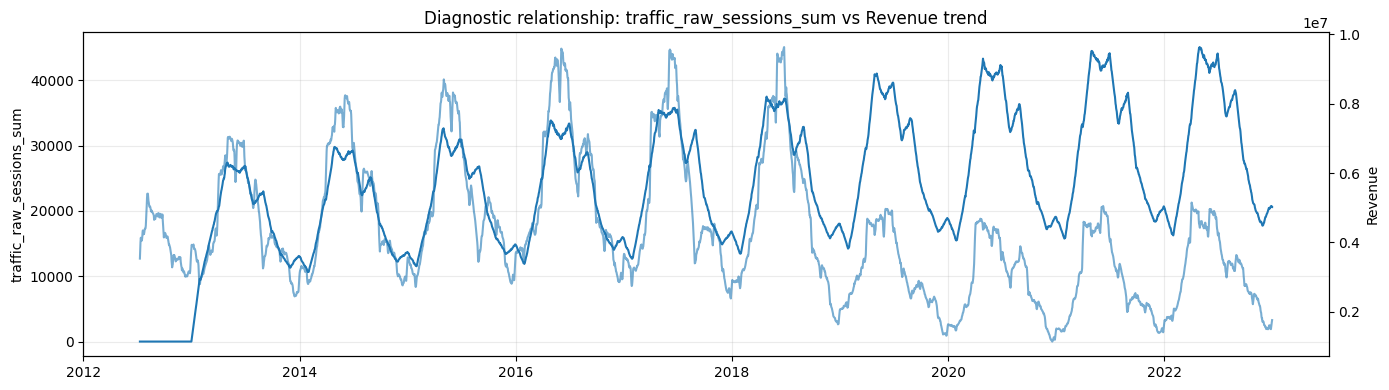

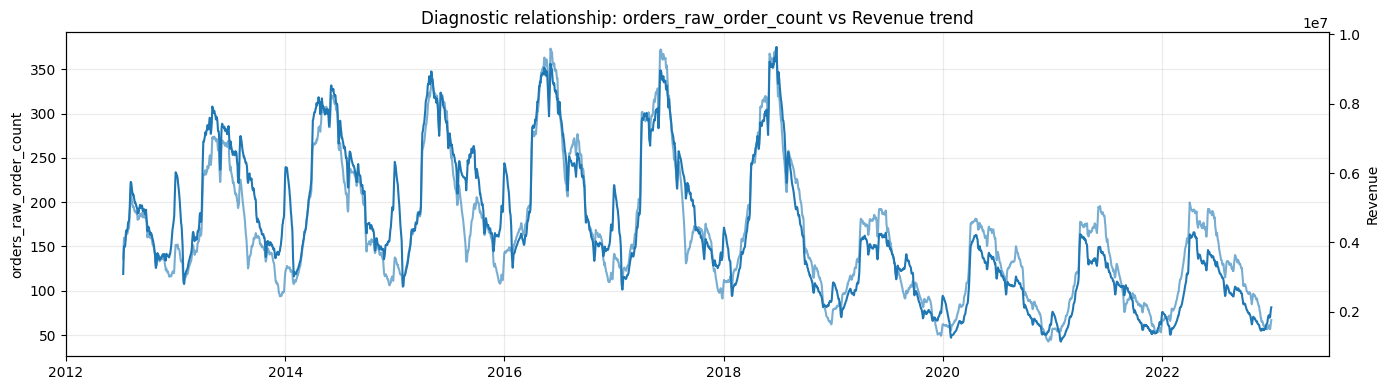

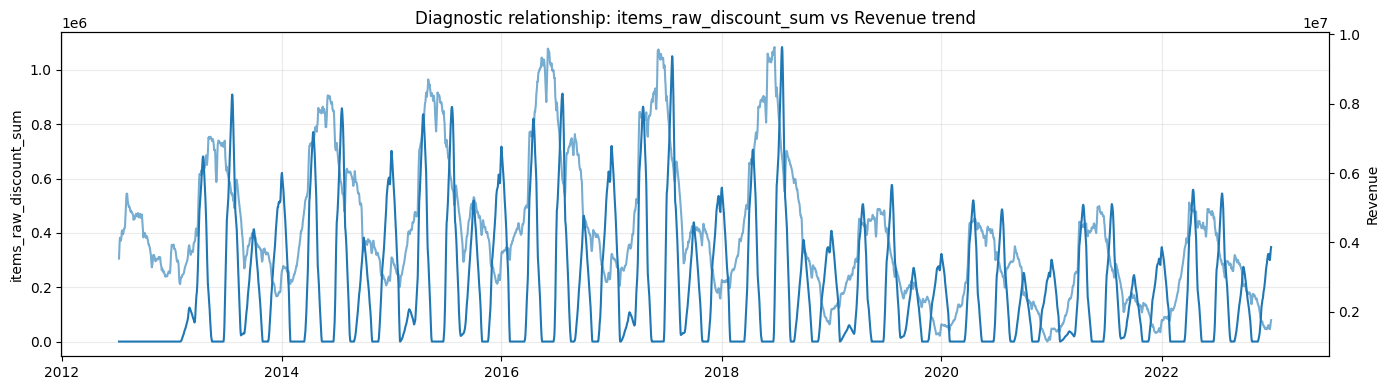

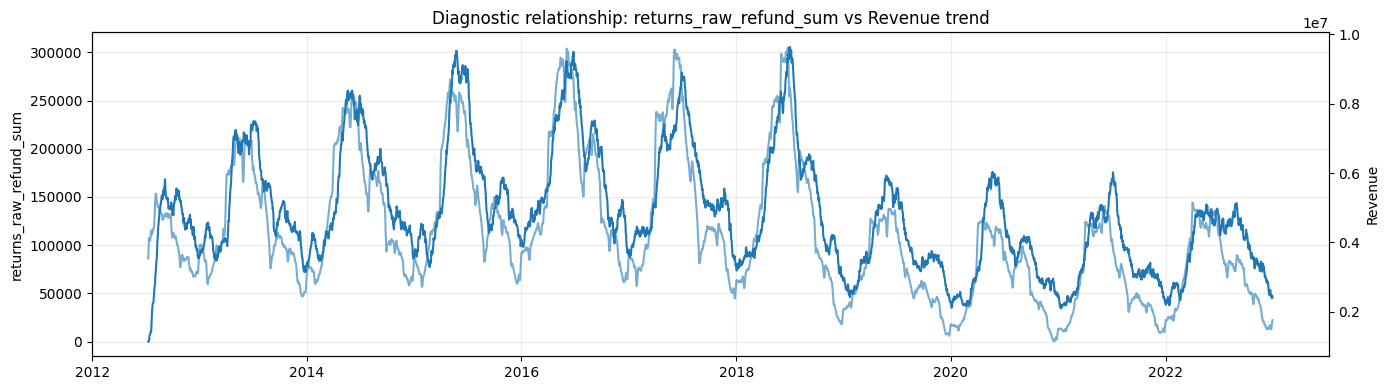

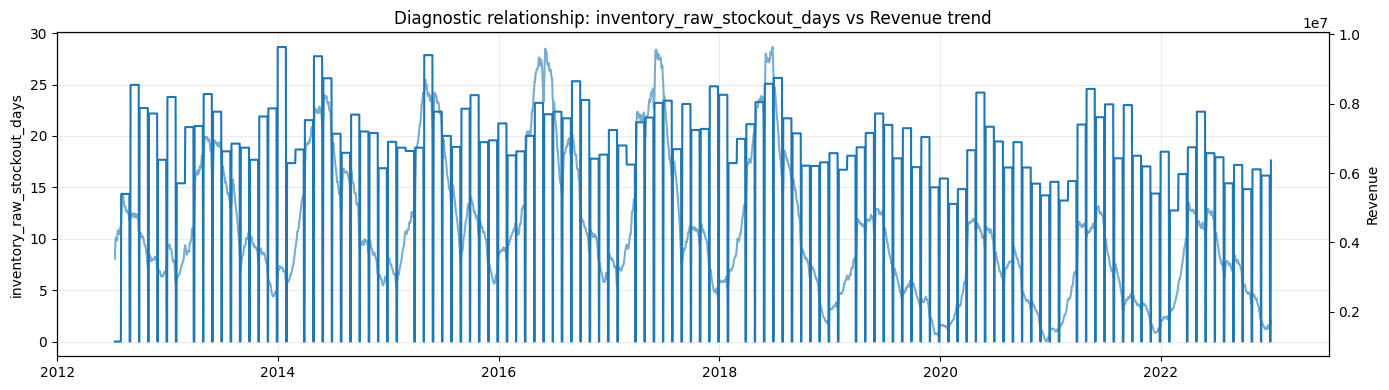

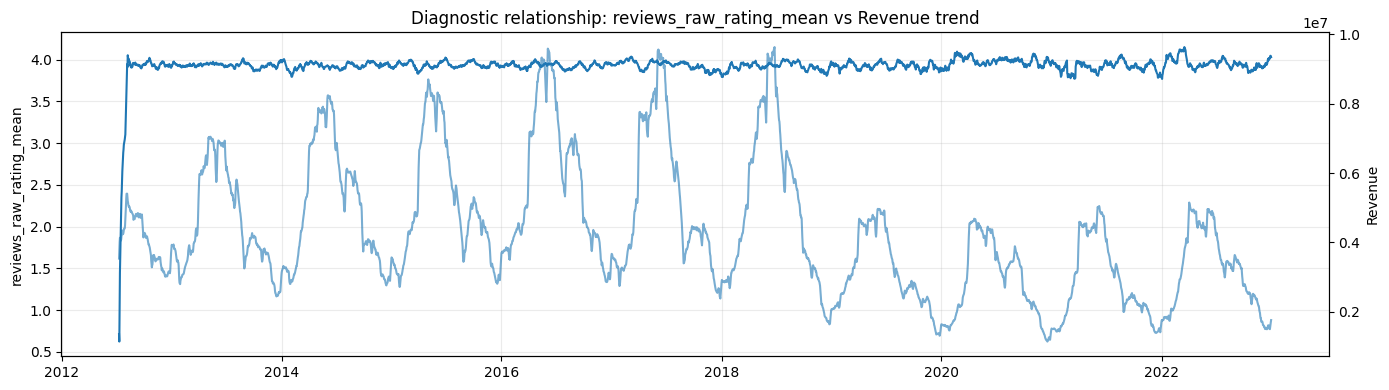

In [30]:
# Diagnostic plots from supporting tables: traffic, promotions, returns, stockouts when available.
if USE_SUPPORT_TABLES and raw_operational_daily.shape[1] > 1:
    diag = raw_operational_daily.merge(sales[["Date", "Revenue"]], on="Date", how="left")
    candidate_plot_cols = [
        "traffic_raw_sessions_sum",
        "orders_raw_order_count",
        "items_raw_discount_sum",
        "returns_raw_refund_sum",
        "inventory_raw_stockout_days",
        "reviews_raw_rating_mean",
    ]
    for col in candidate_plot_cols:
        if col in diag.columns:
            tmp = diag[["Date", col, "Revenue"]].dropna().copy()
            tmp[f"{col}_ma_28"] = tmp[col].rolling(28, min_periods=7).mean()
            fig, ax1 = plt.subplots(figsize=(14, 4))
            ax1.plot(tmp["Date"], tmp[f"{col}_ma_28"], label=f"{col} 28d MA")
            ax1.set_ylabel(col)
            ax2 = ax1.twinx()
            ax2.plot(tmp["Date"], tmp["Revenue"].rolling(28, min_periods=7).mean(), label="Revenue 28d MA", alpha=0.6)
            ax2.set_ylabel("Revenue")
            ax1.set_title(f"Diagnostic relationship: {col} vs Revenue trend")
            ax1.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()
else:
    print("Support-table diagnostics skipped because USE_SUPPORT_TABLES=False or no support features available.")

## 6. Feature engineering pipeline

The feature pipeline combines:

1. **Known features:** calendar and promotion calendar.
2. **Safe historical target features:** lagged and rolling `Revenue`/`COGS`, shifted by at least one day.
3. **Safe historical operational features:** yearly/seasonal lagged and rolling orders, items, web traffic, returns, reviews, shipments, payments, inventory.

The model never sees same-day `Revenue`, same-day `COGS`, or same-day operational results for the forecast date.

In [31]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

def build_base_features() -> pd.DataFrame:
    base = calendar_features.copy()
    base = base.merge(promo_features, on="Date", how="left", suffixes=("", "_promo"))
    # Remove duplicate calendar columns if any accidental suffix was created.
    duplicate_cols = [c for c in base.columns if c.endswith("_promo") and c.replace("_promo", "") in base.columns]
    if duplicate_cols:
        base = base.drop(columns=duplicate_cols)
    base = base.merge(auxiliary_lag_features, on="Date", how="left")
    return base.sort_values("Date").reset_index(drop=True)


def add_vectorized_target_history_features(df: pd.DataFrame, target_cols: list[str] = TARGETS) -> pd.DataFrame:
    """For training rows: target lags/rolls use only prior values via shift, so this is leakage-safe."""
    out = df.sort_values("Date").copy()
    for target in target_cols:
        if target not in out.columns:
            continue
        s = out[target].astype(float)
        for lag in TARGET_LAGS:
            out[f"{target}_lag_{lag}"] = s.shift(lag)
        for win in TARGET_ROLL_WINDOWS:
            shifted = s.shift(1)
            out[f"{target}_rollmean_{win}"] = shifted.rolling(win, min_periods=max(3, win // 4)).mean()
            out[f"{target}_rollstd_{win}"] = shifted.rolling(win, min_periods=max(3, win // 4)).std()
            out[f"{target}_rollmin_{win}"] = shifted.rolling(win, min_periods=max(3, win // 4)).min()
            out[f"{target}_rollmax_{win}"] = shifted.rolling(win, min_periods=max(3, win // 4)).max()
    return out


def make_training_feature_frame(base_features: pd.DataFrame, sales_df: pd.DataFrame) -> pd.DataFrame:
    frame = base_features.merge(sales_df[["Date"] + TARGETS], on="Date", how="left")
    frame = add_vectorized_target_history_features(frame, TARGETS)
    # Keep rows where target is known. Missing lag values are handled by imputers.
    frame = frame[frame[PRIMARY_TARGET].notna()].copy()
    return frame

base_features = build_base_features()
feature_frame = make_training_feature_frame(base_features, sales)

DROP_ALWAYS = set(["Date"] + TARGETS)
FEATURE_COLS = [c for c in feature_frame.columns if c not in DROP_ALWAYS]
assert_no_leakage_columns(FEATURE_COLS)

print(f"Base features: {base_features.shape}")
print(f"Training feature frame: {feature_frame.shape}")
print(f"Model feature count: {len(FEATURE_COLS)}")

display(feature_frame[["Date", "Revenue", "COGS"] + FEATURE_COLS[:10]].head(10))

Leakage guard passed for 381 model features.
Base features: (4381, 304)
Training feature frame: (3833, 384)
Model feature count: 381


,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,weekofyear,quarter,is_weekend,is_month_start,is_month_end
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,27,3,0,0,0
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,27,3,0,0,0
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,27,3,0,0,0
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,27,3,1,0,0
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,27,3,1,0,0
5,2012-07-09,3548386.46,2787841.68,2012,7,9,0,191,28,3,0,0,0
6,2012-07-10,5234938.62,4044438.84,2012,7,10,1,192,28,3,0,0,0
7,2012-07-11,5582884.78,4338313.07,2012,7,11,2,193,28,3,0,0,0
8,2012-07-12,5734632.02,4458811.27,2012,7,12,3,194,28,3,0,0,0
9,2012-07-13,5309511.71,4143402.78,2012,7,13,4,195,28,3,0,0,0


In [32]:
# Feature quality report
missing_rate = feature_frame[FEATURE_COLS].isna().mean().sort_values(ascending=False)
zero_var = feature_frame[FEATURE_COLS].nunique(dropna=False).loc[lambda s: s <= 1]
feature_report = pd.DataFrame({
    "feature": FEATURE_COLS,
    "missing_rate": [missing_rate.get(c, 0) for c in FEATURE_COLS],
    "nunique": [feature_frame[c].nunique(dropna=False) for c in FEATURE_COLS],
})

display(feature_report.sort_values("missing_rate", ascending=False).head(25))
print(f"Zero/constant features: {len(zero_var)}")
if len(zero_var):
    display(zero_var.head(20))

# Drop constants for cleaner models.
CONSTANT_FEATURES = set(zero_var.index.tolist())
FEATURE_COLS = [c for c in FEATURE_COLS if c not in CONSTANT_FEATURES]
assert_no_leakage_columns(FEATURE_COLS)

,feature,missing_rate,nunique
98,items_raw_segment_Premium_gross_value_lag730_r...,0.19593,3083
218,shipments_raw_count_lag730_rollmean_91,0.19593,2837
164,inventory_raw_units_sold_lag730_rollmean_91,0.19593,238
38,items_raw_gross_value_sum_lag730_rollmean_91,0.19593,3083
260,orders_raw_device_type_desktop_lag730_rollmean_91,0.19593,2562
44,payments_raw_value_sum_lag730_rollmean_91,0.19593,3083
158,inventory_raw_units_received_lag730_rollmean_91,0.19593,242
50,items_raw_category_Streetwear_gross_value_lag7...,0.19593,3083
254,items_raw_unique_products_lag730_rollmean_91,0.19593,2604
212,orders_raw_order_status_delivered_lag730_rollm...,0.19593,2820


Zero/constant features: 0
Leakage guard passed for 381 model features.


## 7. Recursive forecasting functions

A key risk in long-horizon forecasting is accidental validation leakage. A normal validation matrix can accidentally use actual validation target lags. This notebook uses **recursive backtesting**: once validation starts, the model only receives prior predictions, not future actual values.

In [33]:
# ============================================================
# 7. RECURSIVE FORECASTING HELPERS
# ============================================================

def target_history_features_for_date(history: pd.DataFrame, current_date: pd.Timestamp, target_cols: list[str] = TARGETS) -> dict:
    """Create target lag/rolling features for one forecast date using only history strictly before current_date."""
    hist = history[history["Date"] < current_date].sort_values("Date")
    hist_idx = hist.set_index("Date")
    features = {}
    for target in target_cols:
        s = hist_idx[target].astype(float) if target in hist_idx.columns else pd.Series(dtype=float)
        for lag in TARGET_LAGS:
            lag_date = current_date - pd.Timedelta(days=lag)
            features[f"{target}_lag_{lag}"] = s.loc[lag_date] if lag_date in s.index else np.nan
        prior = s.dropna()
        for win in TARGET_ROLL_WINDOWS:
            tail = prior.tail(win)
            min_periods = max(3, win // 4)
            if len(tail) >= min_periods:
                features[f"{target}_rollmean_{win}"] = tail.mean()
                features[f"{target}_rollstd_{win}"] = tail.std(ddof=1)
                features[f"{target}_rollmin_{win}"] = tail.min()
                features[f"{target}_rollmax_{win}"] = tail.max()
            else:
                features[f"{target}_rollmean_{win}"] = np.nan
                features[f"{target}_rollstd_{win}"] = np.nan
                features[f"{target}_rollmin_{win}"] = np.nan
                features[f"{target}_rollmax_{win}"] = np.nan
    return features


def feature_row_for_date(base_features: pd.DataFrame, history: pd.DataFrame, current_date: pd.Timestamp, feature_cols: list[str]) -> pd.DataFrame:
    base_row = base_features.loc[base_features["Date"] == current_date].copy()
    if base_row.empty:
        raise ValueError(f"No base features found for date {current_date}")
    hist_feats = target_history_features_for_date(history, current_date, TARGETS)
    for k, v in hist_feats.items():
        base_row[k] = v
    # Ensure exact training feature schema.
    for col in feature_cols:
        if col not in base_row.columns:
            base_row[col] = np.nan
    return base_row[feature_cols]


def clip_predictions(preds: pd.DataFrame, history_sales: pd.DataFrame) -> pd.DataFrame:
    out = preds.copy()
    if not CLIP_FORECASTS:
        return out
    for target in TARGETS:
        lo = 0.0
        hi = float(history_sales[target].quantile(0.999) * 1.35)
        out[target] = out[target].clip(lower=lo, upper=hi)
    return out


def recursive_predict(models_by_target: dict, base_features: pd.DataFrame, history_sales: pd.DataFrame, future_dates: pd.Series | pd.DatetimeIndex, feature_cols: list[str]) -> pd.DataFrame:
    """Forecast target dates one by one, feeding predictions back as future lag history."""
    history = history_sales[["Date"] + TARGETS].copy().sort_values("Date")
    preds = []
    future_dates = pd.to_datetime(pd.Series(future_dates)).sort_values().tolist()
    bounds = {target: (0.0, float(history_sales[target].quantile(0.999) * 1.35)) for target in TARGETS}

    for d in future_dates:
        x_row = feature_row_for_date(base_features, history, d, feature_cols)
        row_pred = {"Date": d}
        for target in TARGETS:
            model = models_by_target[target]
            pred = float(model.predict(x_row)[0])
            if CLIP_FORECASTS:
                lo, hi = bounds[target]
                pred = float(np.clip(pred, lo, hi))
            row_pred[target] = pred
        preds.append(row_pred)
        history = pd.concat([history, pd.DataFrame([row_pred])], ignore_index=True)

    preds_df = pd.DataFrame(preds)
    preds_df = clip_predictions(preds_df, history_sales)
    return preds_df


def seasonal_naive_recursive(history_sales: pd.DataFrame, future_dates: pd.Series | pd.DatetimeIndex) -> pd.DataFrame:
    """Simple fallback baseline: use 365-day lag when available, otherwise 7-day lag, recursively."""
    history = history_sales[["Date"] + TARGETS].copy().sort_values("Date")
    hist_idx = history.set_index("Date")
    rows = []
    for d in pd.to_datetime(pd.Series(future_dates)).sort_values().tolist():
        row = {"Date": d}
        for target in TARGETS:
            s = hist_idx[target]
            value = np.nan
            for lag in [365, 364, 371, 7, 14, 28]:
                lag_date = d - pd.Timedelta(days=lag)
                if lag_date in s.index and pd.notna(s.loc[lag_date]):
                    value = float(s.loc[lag_date])
                    break
            if pd.isna(value):
                value = float(s.tail(28).mean())
            row[target] = max(0.0, value)
        rows.append(row)
        hist_idx.loc[d, TARGETS] = [row[t] for t in TARGETS]
    return pd.DataFrame(rows)

## 8. Model registry

The registry supports fast iteration and fuller leaderboard-grade runs. Optional libraries are used only if installed; the notebook remains runnable with scikit-learn alone.

In [34]:
# ============================================================
# 8. MODEL REGISTRY
# ============================================================

def get_feature_types(df: pd.DataFrame, feature_cols: list[str]) -> tuple[list[str], list[str]]:
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]
    return numeric_cols, categorical_cols


def make_preprocessor(df: pd.DataFrame, feature_cols: list[str], scale_numeric: bool = False) -> ColumnTransformer:
    numeric_cols, categorical_cols = get_feature_types(df, feature_cols)
    if scale_numeric:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    else:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    transformers = [("num", num_pipe, numeric_cols)]
    if categorical_cols:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_cols))
    return ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)


def optional_model_registry() -> dict:
    registry = {}
    if USE_OPTIONAL_GBDT:
        try:
            from lightgbm import LGBMRegressor
            registry["lgbm"] = LGBMRegressor(
                objective="regression",
                n_estimators=900 if RUN_MODE == "quick" else 1800,
                learning_rate=0.035,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.5,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            )
        except Exception as e:
            print(f"LightGBM unavailable; skipped. Reason: {e}")
        try:
            from xgboost import XGBRegressor
            registry["xgb"] = XGBRegressor(
                n_estimators=700 if RUN_MODE == "quick" else 1400,
                learning_rate=0.035,
                max_depth=4,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            )
        except Exception as e:
            print(f"XGBoost unavailable; skipped. Reason: {e}")
    return registry


def build_model_registry() -> dict:
    registry = {
        "ridge": Ridge(alpha=10.0, random_state=RANDOM_SEED),
        "huber": HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=500),
        "extra_trees": ExtraTreesRegressor(
            n_estimators=250 if RUN_MODE == "quick" else 700,
            max_depth=18 if RUN_MODE == "quick" else None,
            min_samples_leaf=3,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        "random_forest": RandomForestRegressor(
            n_estimators=180 if RUN_MODE == "quick" else 500,
            max_depth=18 if RUN_MODE == "quick" else None,
            min_samples_leaf=3,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        # HistGradientBoosting is strong and available in sklearn, but it can be slower in full mode.
        "hist_gbdt": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250 if RUN_MODE == "quick" else 700,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_SEED,
        ),
    }
    registry.update(optional_model_registry())
    if RUN_MODE == "quick":
        # Keep quick mode lean. Add/remove candidates here during experimentation.
        keep = ["ridge", "extra_trees", "hist_gbdt", "lgbm"]
        registry = {k: v for k, v in registry.items() if k in keep}
    return registry


def make_pipeline(model, train_df: pd.DataFrame, feature_cols: list[str], scale_numeric: bool = False) -> Pipeline:
    preprocessor = make_preprocessor(train_df, feature_cols, scale_numeric=scale_numeric)
    return Pipeline([("prep", preprocessor), ("model", model)])


def fit_models_for_targets(train_df: pd.DataFrame, feature_cols: list[str], model_key: str, base_model) -> dict:
    models = {}
    X = train_df[feature_cols]
    for target in TARGETS:
        y = train_df[target].astype(float)
        # Scale numeric only for linear models.
        scale = model_key in ["ridge", "huber"]
        pipe = make_pipeline(clone(base_model), train_df, feature_cols, scale_numeric=scale)
        pipe.fit(X, y)
        models[target] = pipe
    return models

MODEL_REGISTRY = build_model_registry()
print("Available model candidates:", list(MODEL_REGISTRY.keys()))

LightGBM unavailable; skipped. Reason: No module named 'lightgbm'
Available model candidates: ['ridge', 'extra_trees', 'hist_gbdt']


## 9. Time-aware recursive backtesting

This is the most important technical-quality section. The validation simulates how Kaggle forecasting works: train on the past, forecast a future horizon day by day, and only feed predictions back into later lag features.

In [35]:
# ============================================================
# 9. TIME-AWARE RECURSIVE BACKTESTING
# ============================================================

def make_backtest_folds(sales_df: pd.DataFrame, test_df: pd.DataFrame) -> list[dict]:
    test_horizon = len(test_df)
    horizon = CV_HORIZON_DAYS if CV_HORIZON_DAYS is not None else test_horizon
    horizon = min(horizon, 548)  # safety cap for very long local experiments
    last_train_date = sales_df["Date"].max()
    folds = []
    # Anchor fold ends backwards from the end of the training set.
    for i in range(N_CV_FOLDS):
        valid_end = last_train_date - pd.Timedelta(days=i * max(90, horizon // 2))
        valid_start = valid_end - pd.Timedelta(days=horizon - 1)
        train_end = valid_start - pd.Timedelta(days=1)
        # Need enough history for 730-day lags.
        if train_end <= sales_df["Date"].min() + pd.Timedelta(days=800):
            continue
        folds.append({
            "fold": N_CV_FOLDS - i,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            "horizon_days": horizon,
        })
    folds = sorted(folds, key=lambda x: x["valid_start"])
    return folds


def score_predictions(actual: pd.DataFrame, pred: pd.DataFrame, model_key: str, fold_id: int) -> dict:
    merged = actual[["Date"] + TARGETS].merge(pred[["Date"] + TARGETS], on="Date", suffixes=("_actual", "_pred"))
    row = {"model": model_key, "fold": fold_id, "n_valid": len(merged)}
    for target in TARGETS:
        row.update(metric_dict(merged[f"{target}_actual"], merged[f"{target}_pred"], prefix=f"{target}_"))
    return row


def run_backtest(model_key: str, base_model, folds: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    metrics_rows = []
    pred_rows = []
    for fold in folds:
        train_end = fold["train_end"]
        valid_start = fold["valid_start"]
        valid_end = fold["valid_end"]
        fold_id = fold["fold"]

        train_fold = feature_frame[feature_frame["Date"] <= train_end].copy()
        valid_dates = pd.date_range(valid_start, valid_end, freq="D")
        actual_valid = sales[(sales["Date"] >= valid_start) & (sales["Date"] <= valid_end)].copy()
        if actual_valid.empty:
            continue

        print(f"{model_key} | fold={fold_id} | train<= {train_end.date()} | valid {valid_start.date()} to {valid_end.date()} ({len(actual_valid)} days)")
        models = fit_models_for_targets(train_fold, FEATURE_COLS, model_key, base_model)
        history = sales[sales["Date"] <= train_end].copy()
        pred = recursive_predict(models, base_features, history, actual_valid["Date"], FEATURE_COLS)
        pred["model"] = model_key
        pred["fold"] = fold_id
        metrics_rows.append(score_predictions(actual_valid, pred, model_key, fold_id))
        pred_rows.append(pred)

    return pd.DataFrame(metrics_rows), pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()


def run_baseline_backtest(folds: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    preds = []
    for fold in folds:
        train_end = fold["train_end"]
        actual_valid = sales[(sales["Date"] >= fold["valid_start"]) & (sales["Date"] <= fold["valid_end"])].copy()
        if actual_valid.empty:
            continue
        history = sales[sales["Date"] <= train_end].copy()
        pred = seasonal_naive_recursive(history, actual_valid["Date"])
        pred["model"] = "seasonal_naive"
        pred["fold"] = fold["fold"]
        rows.append(score_predictions(actual_valid, pred, "seasonal_naive", fold["fold"]))
        preds.append(pred)
    return pd.DataFrame(rows), pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()

folds = make_backtest_folds(sales, test_frame)
display(pd.DataFrame(folds))

if RUN_BACKTEST:
    all_metric_rows = []
    all_backtest_preds = []

    base_metrics, base_preds = run_baseline_backtest(folds)
    all_metric_rows.append(base_metrics)
    all_backtest_preds.append(base_preds)

    for key, model in MODEL_REGISTRY.items():
        metrics, preds = run_backtest(key, model, folds)
        all_metric_rows.append(metrics)
        all_backtest_preds.append(preds)

    cv_metrics = pd.concat(all_metric_rows, ignore_index=True)
    cv_preds = pd.concat(all_backtest_preds, ignore_index=True)
    save_table(cv_metrics, "cv_metrics_by_fold.csv")
    save_table(cv_preds, "cv_predictions.csv")

    display(cv_metrics.sort_values(["Revenue_rmse", "Revenue_mae"]).head(20))
else:
    cv_metrics = pd.DataFrame()
    cv_preds = pd.DataFrame()
    print("Backtesting skipped. Set RUN_BACKTEST=True to evaluate model candidates.")

,fold,train_end,valid_start,valid_end,horizon_days
0,1,2022-04-05,2022-04-06,2022-10-02,180
1,2,2022-07-04,2022-07-05,2022-12-31,180


ridge | fold=1 | train<= 2022-04-05 | valid 2022-04-06 to 2022-10-02 (180 days)
ridge | fold=2 | train<= 2022-07-04 | valid 2022-07-05 to 2022-12-31 (180 days)
extra_trees | fold=1 | train<= 2022-04-05 | valid 2022-04-06 to 2022-10-02 (180 days)
extra_trees | fold=2 | train<= 2022-07-04 | valid 2022-07-05 to 2022-12-31 (180 days)
hist_gbdt | fold=1 | train<= 2022-04-05 | valid 2022-04-06 to 2022-10-02 (180 days)
hist_gbdt | fold=2 | train<= 2022-07-04 | valid 2022-07-05 to 2022-12-31 (180 days)


,model,fold,n_valid,Revenue_mae,Revenue_rmse,Revenue_r2,COGS_mae,COGS_rmse,COGS_r2
7,hist_gbdt,2,180,5.686314e+05,7.948588e+05,0.578192,5.190709e+05,6.908200e+05,0.543388
5,extra_trees,2,180,6.080989e+05,8.639280e+05,0.501702,5.437119e+05,7.587409e+05,0.449187
6,hist_gbdt,1,180,7.161144e+05,9.283379e+05,0.628225,6.346411e+05,8.085590e+05,0.595221
4,extra_trees,1,180,7.424515e+05,9.938052e+05,0.573940,6.678972e+05,8.793035e+05,0.521290
1,seasonal_naive,2,180,8.026370e+05,1.153288e+06,0.112006,6.426999e+05,9.082566e+05,0.210714
0,seasonal_naive,1,180,9.844520e+05,1.328096e+06,0.239101,7.828649e+05,1.052144e+06,0.314598
2,ridge,1,180,1.282427e+06,1.591275e+06,-0.092343,1.073261e+06,1.330715e+06,-0.096390
3,ridge,2,180,1.557738e+06,1.801313e+06,-1.166270,1.301379e+06,1.505000e+06,-1.167156


,Revenue_mae,Revenue_rmse,Revenue_r2,COGS_mae,COGS_rmse,COGS_r2
model,,,,,,
hist_gbdt,6.423729e+05,8.615983e+05,0.603209,5.768560e+05,7.496895e+05,0.569304
extra_trees,6.752752e+05,9.288666e+05,0.537821,6.058046e+05,8.190222e+05,0.485238
seasonal_naive,8.935445e+05,1.240692e+06,0.175553,7.127824e+05,9.802004e+05,0.262656
ridge,1.420083e+06,1.696294e+06,-0.629307,1.187320e+06,1.417857e+06,-0.631773


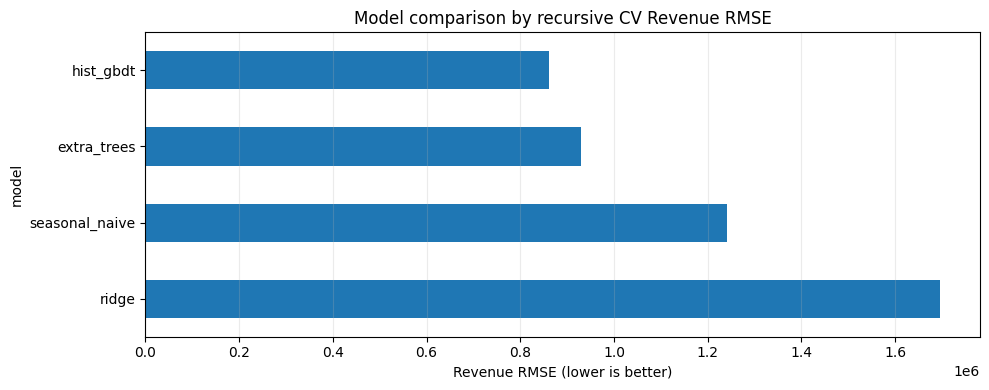

Best model by Revenue RMSE: hist_gbdt


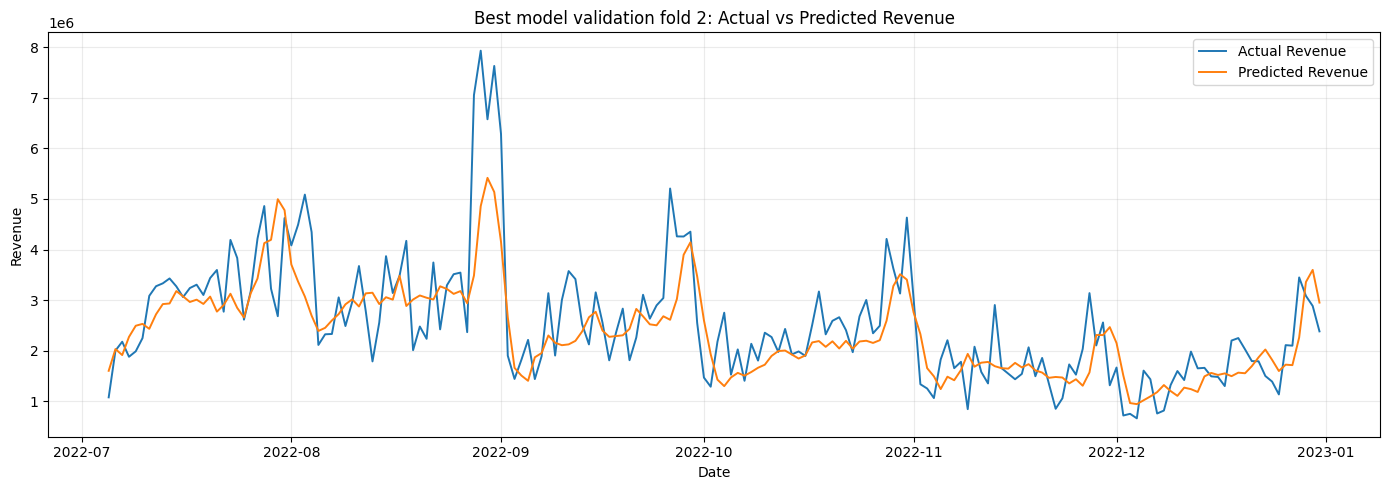

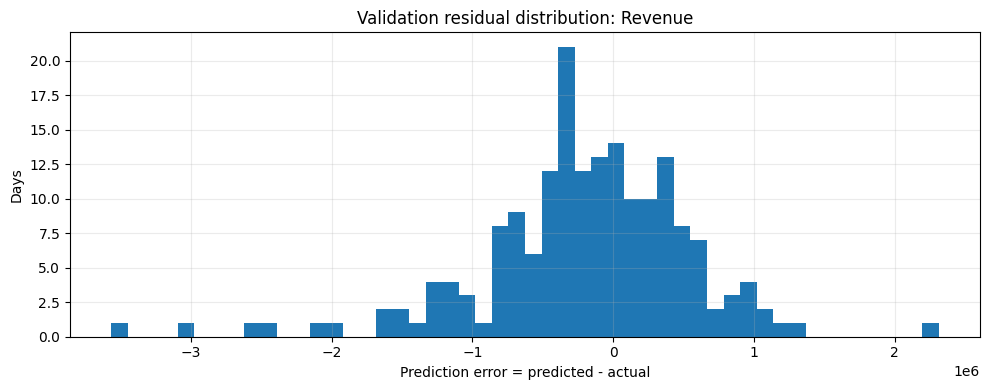

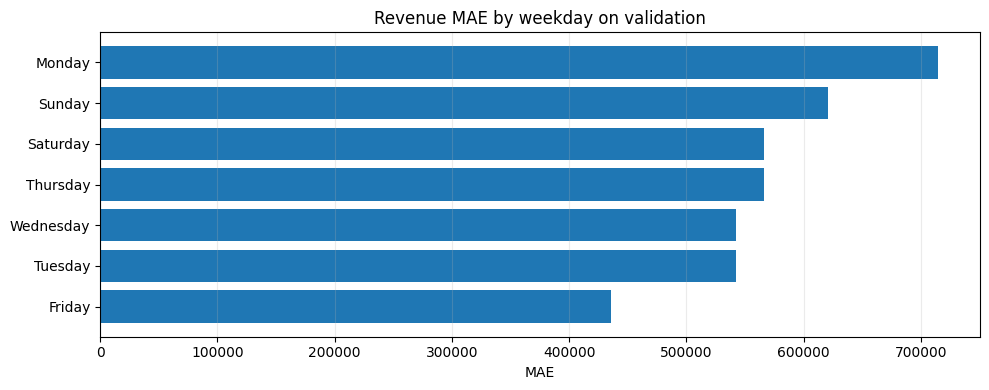

In [36]:
# Backtest comparison plots
if RUN_BACKTEST and not cv_metrics.empty:
    summary_cols = [
        "Revenue_mae", "Revenue_rmse", "Revenue_r2",
        "COGS_mae", "COGS_rmse", "COGS_r2",
    ]
    cv_summary = cv_metrics.groupby("model")[summary_cols].mean().sort_values("Revenue_rmse")
    display(cv_summary)
    save_table(cv_summary.reset_index(), "cv_metrics_summary.csv")

    fig, ax = plt.subplots(figsize=(10, 4))
    cv_summary["Revenue_rmse"].sort_values(ascending=False).plot(kind="barh", ax=ax)
    ax.set_title("Model comparison by recursive CV Revenue RMSE")
    ax.set_xlabel("Revenue RMSE (lower is better)")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    BEST_MODEL_KEY = cv_summary.index[0]
    print(f"Best model by Revenue RMSE: {BEST_MODEL_KEY}")

    # Last fold actual vs predicted plot for best model.
    last_fold = cv_preds[cv_preds["model"] == BEST_MODEL_KEY]["fold"].max()
    pred_last = cv_preds[(cv_preds["model"] == BEST_MODEL_KEY) & (cv_preds["fold"] == last_fold)].copy()
    actual_last = sales[["Date"] + TARGETS].merge(pred_last[["Date"] + TARGETS], on="Date", suffixes=("_actual", "_pred"))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(actual_last["Date"], actual_last["Revenue_actual"], label="Actual Revenue", linewidth=1.4)
    ax.plot(actual_last["Date"], actual_last["Revenue_pred"], label="Predicted Revenue", linewidth=1.4)
    ax.set_title(f"Best model validation fold {last_fold}: Actual vs Predicted Revenue")
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    residual = actual_last["Revenue_pred"] - actual_last["Revenue_actual"]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(residual, bins=50)
    ax.set_title("Validation residual distribution: Revenue")
    ax.set_xlabel("Prediction error = predicted - actual")
    ax.set_ylabel("Days")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    actual_last["abs_error"] = residual.abs()
    actual_last["dayofweek"] = actual_last["Date"].dt.day_name()
    dow_error = actual_last.groupby("dayofweek")["abs_error"].mean().reindex(weekday_order)
    plot_barh(dow_error, "Revenue MAE by weekday on validation", "MAE", top_n=7)
else:
    BEST_MODEL_KEY = "extra_trees" if "extra_trees" in MODEL_REGISTRY else next(iter(MODEL_REGISTRY.keys()))
    print(f"Backtest unavailable; defaulting BEST_MODEL_KEY={BEST_MODEL_KEY}")

## 10. Optional tuning loop

This section is deliberately separated. Use it only after the feature pipeline and leakage checks are stable. It evaluates a compact parameter grid using the same recursive backtest logic.

In [37]:
# ============================================================
# 10. OPTIONAL TUNING
# ============================================================

TUNED_MODELS = {}

if RUN_TUNING:
    tuning_grid = []

    if "extra_trees" in MODEL_REGISTRY:
        for n_estimators in ([300, 600] if RUN_MODE == "full" else [200]):
            for min_leaf in [1, 3, 5]:
                tuning_grid.append((f"extra_trees_ne{n_estimators}_leaf{min_leaf}", ExtraTreesRegressor(
                    n_estimators=n_estimators,
                    max_depth=None,
                    min_samples_leaf=min_leaf,
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                )))

    if "hist_gbdt" in MODEL_REGISTRY:
        for lr in [0.03, 0.05, 0.08]:
            for leaves in [15, 31]:
                tuning_grid.append((f"hist_gbdt_lr{lr}_leaf{leaves}", HistGradientBoostingRegressor(
                    learning_rate=lr,
                    max_iter=500 if RUN_MODE == "full" else 250,
                    max_leaf_nodes=leaves,
                    l2_regularization=0.05,
                    random_state=RANDOM_SEED,
                )))

    if "lgbm" in MODEL_REGISTRY:
        try:
            from lightgbm import LGBMRegressor
            for lr in [0.02, 0.035, 0.06]:
                for leaves in [15, 31, 63]:
                    tuning_grid.append((f"lgbm_lr{lr}_leaf{leaves}", LGBMRegressor(
                        objective="regression",
                        n_estimators=1600 if RUN_MODE == "full" else 800,
                        learning_rate=lr,
                        num_leaves=leaves,
                        subsample=0.85,
                        colsample_bytree=0.85,
                        reg_lambda=1.5,
                        random_state=RANDOM_SEED,
                        n_jobs=-1,
                    )))
        except Exception:
            pass

    tuning_rows = []
    for key, model in tuning_grid:
        metrics, _ = run_backtest(key, model, folds)
        if not metrics.empty:
            row = metrics.groupby("model")[["Revenue_mae", "Revenue_rmse", "Revenue_r2", "COGS_mae", "COGS_rmse", "COGS_r2"]].mean().reset_index().iloc[0].to_dict()
            tuning_rows.append(row)
            TUNED_MODELS[key] = model

    tuning_results = pd.DataFrame(tuning_rows).sort_values("Revenue_rmse")
    display(tuning_results)
    save_table(tuning_results, "tuning_results.csv")
    if not tuning_results.empty:
        BEST_MODEL_KEY = tuning_results.iloc[0]["model"]
        MODEL_REGISTRY[BEST_MODEL_KEY] = TUNED_MODELS[BEST_MODEL_KEY]
        print(f"Tuning selected best model: {BEST_MODEL_KEY}")
else:
    print("Tuning skipped. Set RUN_TUNING=True after quick pipeline validation.")

Tuning skipped. Set RUN_TUNING=True after quick pipeline validation.


## 11. Final training and Kaggle submission generation

This block trains on all available training dates and forecasts the test horizon recursively. It writes `outputs/submission.csv` and preserves the original test/sample order.

In [38]:
# ============================================================
# 11. FINAL TRAINING AND SUBMISSION
# ============================================================

final_model = MODEL_REGISTRY.get(BEST_MODEL_KEY)
if final_model is None:
    print(f"Best model key {BEST_MODEL_KEY} not found in registry. Falling back to extra_trees.")
    BEST_MODEL_KEY = "extra_trees" if "extra_trees" in MODEL_REGISTRY else next(iter(MODEL_REGISTRY.keys()))
    final_model = MODEL_REGISTRY[BEST_MODEL_KEY]

print(f"Training final model: {BEST_MODEL_KEY}")
final_train_df = feature_frame.copy()
final_models = fit_models_for_targets(final_train_df, FEATURE_COLS, BEST_MODEL_KEY, final_model)

future_dates = test_frame["Date"].copy()
forecast = recursive_predict(final_models, base_features, sales, future_dates, FEATURE_COLS)

# Preserve required order from test_frame/sample_submission.
submission = test_frame[["Date"]].merge(forecast, on="Date", how="left")
for target in TARGETS:
    if submission[target].isna().any():
        # Last-resort fallback for missing dates.
        fallback = seasonal_naive_recursive(sales, submission.loc[submission[target].isna(), "Date"])
        submission = submission.drop(columns=[target]).merge(fallback[["Date", target]], on="Date", how="left")
    submission[target] = submission[target].astype(float).clip(lower=0)

submission_out = submission[["Date"] + TARGETS].copy()
submission_out["Date"] = submission_out["Date"].dt.strftime("%Y-%m-%d")
submission_path = OUTPUT_DIR / "submission.csv"
submission_out.to_csv(submission_path, index=False)
display(submission_out.head())
display(submission_out.tail())

Training final model: hist_gbdt


,Date,Revenue,COGS
0,2023-01-01,2.294417e+06,1.977602e+06
1,2023-01-02,1.538984e+06,1.537729e+06
2,2023-01-03,1.045755e+06,1.161867e+06
3,2023-01-04,8.612847e+05,7.921161e+05
4,2023-01-05,1.090854e+06,9.296105e+05


,Date,Revenue,COGS
543,2024-06-27,7.491388e+06,6.178490e+06
544,2024-06-28,6.820357e+06,6.242922e+06
545,2024-06-29,6.164054e+06,6.165176e+06
546,2024-06-30,6.978332e+06,6.146768e+06
547,2024-07-01,6.886774e+06,5.821054e+06


## 12. Final forecast diagnostics and planning views

These outputs turn the forecast into management-ready views. The objective is to move from model output to operating decisions.

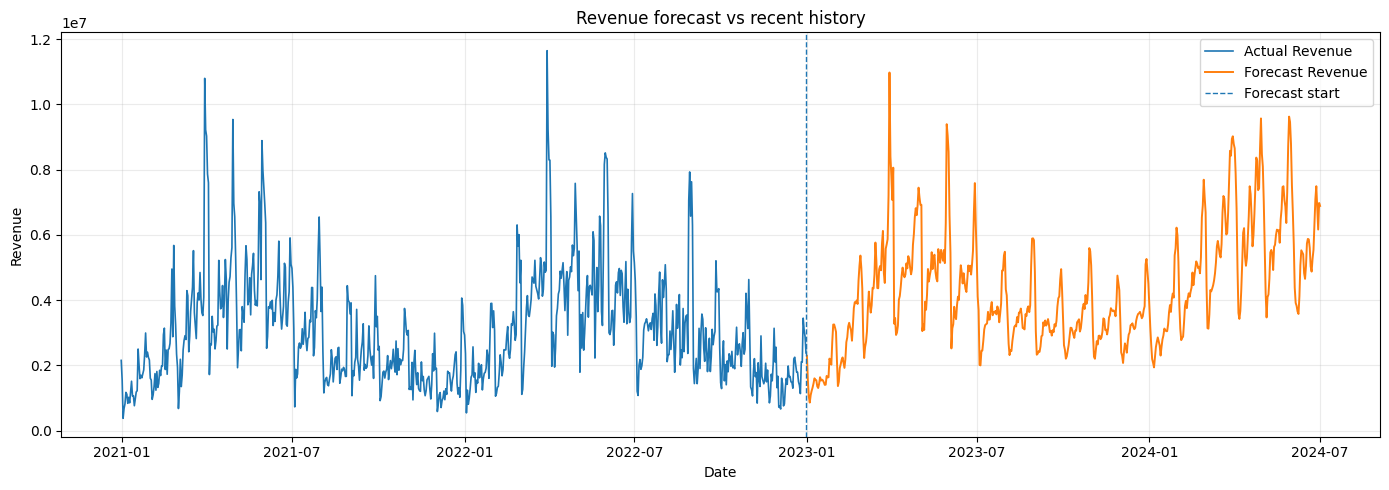

,month,forecast_revenue,forecast_cogs,forecast_margin,avg_margin_rate,peak_daily_revenue,forecast_margin_rate
0,2023-01,5.390338e+07,4.849685e+07,5.406526e+06,0.085837,3.254524e+06,0.100300
1,2023-02,8.639040e+07,6.584502e+07,2.054538e+07,0.239012,5.365529e+06,0.237820
2,2023-03,1.503109e+08,1.186443e+08,3.166656e+07,0.229552,1.097543e+07,0.210674
3,2023-04,1.568992e+08,1.268387e+08,3.006050e+07,0.188321,8.059450e+06,0.191591
4,2023-05,1.643824e+08,1.264391e+08,3.794336e+07,0.228991,9.391564e+06,0.230824
5,2023-06,1.449093e+08,1.191881e+08,2.572127e+07,0.173309,8.542300e+06,0.177499
6,2023-07,1.128426e+08,9.982426e+07,1.301829e+07,0.110944,5.483434e+06,0.115367
7,2023-08,1.125118e+08,9.467958e+07,1.783223e+07,0.164912,5.894208e+06,0.158492
8,2023-09,9.968779e+07,8.104005e+07,1.864774e+07,0.189579,4.949552e+06,0.187061
9,2023-10,1.060678e+08,7.969408e+07,2.637368e+07,0.253653,5.596398e+06,0.248649


,Date,Revenue,COGS,gross_margin_rate
88,2023-03-30,1.097543e+07,9.460637e+06,0.138016
514,2024-05-29,9.622872e+06,8.462345e+06,0.120601
484,2024-04-29,9.567784e+06,8.279141e+06,0.134686
515,2024-05-30,9.459959e+06,8.047697e+06,0.149288
149,2023-05-30,9.391564e+06,6.619501e+06,0.295165
150,2023-05-31,9.050708e+06,7.168166e+06,0.207999
454,2024-03-30,9.021151e+06,6.546085e+06,0.274363
453,2024-03-29,8.942127e+06,6.942655e+06,0.223601
516,2024-05-31,8.799816e+06,7.477858e+06,0.150226
455,2024-03-31,8.783514e+06,6.708007e+06,0.236296


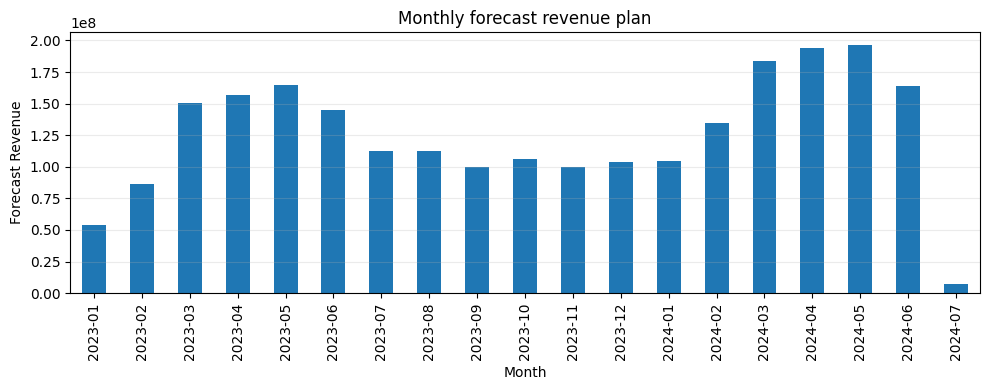

In [39]:
# ============================================================
# 12. FINAL FORECAST DIAGNOSTICS
# ============================================================

forecast_view = submission.copy()
forecast_view["gross_margin"] = forecast_view["Revenue"] - forecast_view["COGS"]
forecast_view["gross_margin_rate"] = np.where(forecast_view["Revenue"] > 0, forecast_view["gross_margin"] / forecast_view["Revenue"], np.nan)
forecast_view["month"] = forecast_view["Date"].dt.to_period("M").astype(str)

# Forecast plot against recent history.
history_tail = sales[sales["Date"] >= sales["Date"].max() - pd.Timedelta(days=730)].copy()
history_tail["period"] = "actual"
forecast_plot = forecast_view[["Date", "Revenue", "COGS"]].copy()
forecast_plot["period"] = "forecast"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(history_tail["Date"], history_tail["Revenue"], label="Actual Revenue", linewidth=1.2)
ax.plot(forecast_plot["Date"], forecast_plot["Revenue"], label="Forecast Revenue", linewidth=1.4)
ax.axvline(sales["Date"].max(), linestyle="--", linewidth=1.0, label="Forecast start")
ax.set_title("Revenue forecast vs recent history")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

monthly_plan = forecast_view.groupby("month").agg(
    forecast_revenue=("Revenue", "sum"),
    forecast_cogs=("COGS", "sum"),
    forecast_margin=("gross_margin", "sum"),
    avg_margin_rate=("gross_margin_rate", "mean"),
    peak_daily_revenue=("Revenue", "max"),
).reset_index()
monthly_plan["forecast_margin_rate"] = monthly_plan["forecast_margin"] / monthly_plan["forecast_revenue"].replace(0, np.nan)
monthly_plan = monthly_plan.sort_values("month")
display(monthly_plan)
save_table(monthly_plan, "monthly_forecast_plan.csv")

# High demand days: useful for inventory and logistics staffing.
high_demand_threshold = forecast_view["Revenue"].quantile(0.90)
high_demand_days = forecast_view[forecast_view["Revenue"] >= high_demand_threshold].sort_values("Revenue", ascending=False)
display(high_demand_days[["Date", "Revenue", "COGS", "gross_margin_rate"]].head(30))
save_table(high_demand_days[["Date", "Revenue", "COGS", "gross_margin_rate"]], "high_demand_days.csv")

fig, ax = plt.subplots(figsize=(10, 4))
monthly_plan.plot(x="month", y="forecast_revenue", kind="bar", ax=ax, legend=False)
ax.set_title("Monthly forecast revenue plan")
ax.set_xlabel("Month")
ax.set_ylabel("Forecast Revenue")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

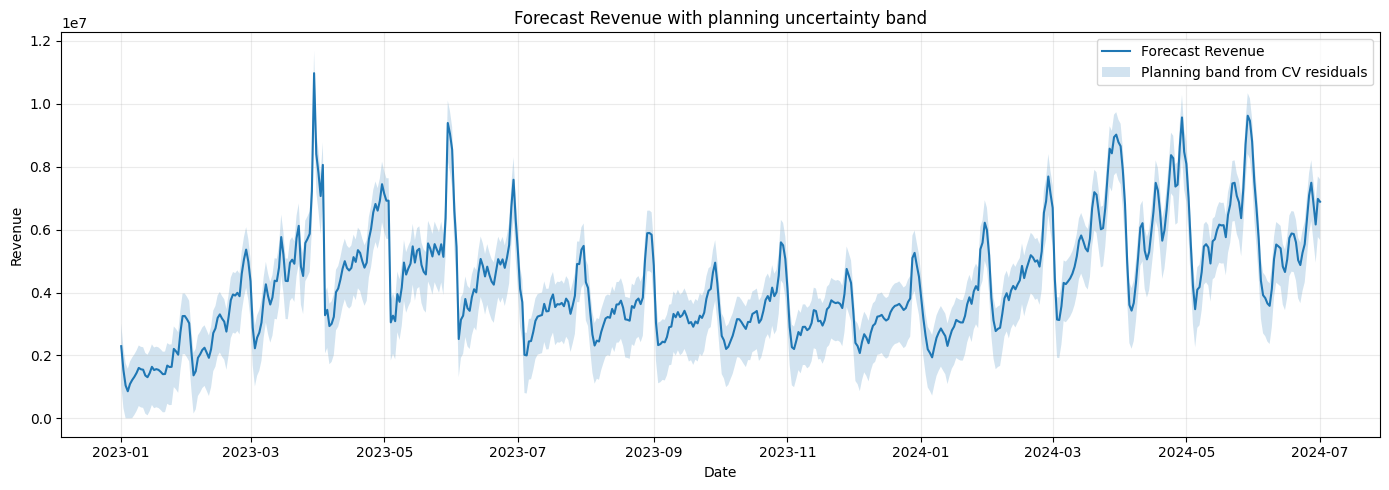

In [40]:
# CV residual-based uncertainty band for planning, not for Kaggle submission.
if RUN_BACKTEST and not cv_preds.empty:
    best_cv = cv_preds[cv_preds["model"] == BEST_MODEL_KEY].merge(sales[["Date", "Revenue"]], on="Date", suffixes=("_pred", "_actual"))
    if not best_cv.empty:
        residuals = best_cv["Revenue_pred"] - best_cv["Revenue_actual"]
        q_low, q_high = residuals.quantile([0.10, 0.90]).values
        forecast_view["revenue_low_p10"] = (forecast_view["Revenue"] - abs(q_low)).clip(lower=0)
        forecast_view["revenue_high_p90"] = (forecast_view["Revenue"] + abs(q_high)).clip(lower=0)

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(forecast_view["Date"], forecast_view["Revenue"], label="Forecast Revenue")
        ax.fill_between(forecast_view["Date"], forecast_view["revenue_low_p10"], forecast_view["revenue_high_p90"], alpha=0.2, label="Planning band from CV residuals")
        ax.set_title("Forecast Revenue with planning uncertainty band")
        ax.set_xlabel("Date")
        ax.set_ylabel("Revenue")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Uncertainty band skipped because CV predictions are unavailable.")

## 13. Explainability: what the model learned

The competition requires model explainability. This section produces feature importance and optional SHAP. Business interpretation should be based on stable patterns across backtest folds, not a single attractive chart.

No native feature importance for Revenue; use permutation importance below.
No native feature importance for COGS; use permutation importance below.


Revenue_lag_1                                        270353.755931
Revenue_lag_7                                         31608.087531
day                                                   16989.135050
COGS_lag_28                                           16221.996828
orders_raw_payment_method_paypal_lag_365              13161.926428
Revenue_rollmin_7                                     10146.781886
items_raw_category_Streetwear_gross_value_lag_730      8861.764308
Revenue_lag_28                                         7530.192108
COGS_lag_7                                             7388.917095
dayofweek                                              6127.115281
items_raw_gross_value_sum_lag_365                      5420.199217
Revenue_lag_14                                         5407.759619
COGS_lag_365                                           4925.004906
dayofweek_cos                                          4359.066552
items_raw_segment_Activewear_gross_value_lag_365       4301.15

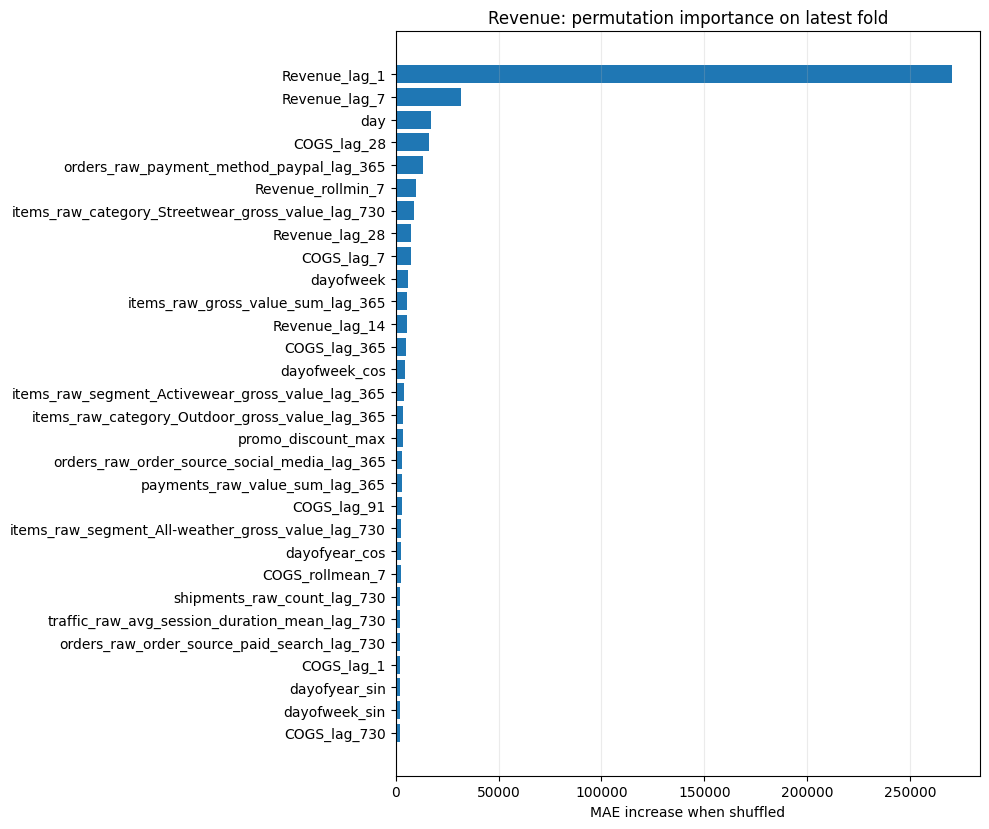

In [41]:
# ============================================================
# 13. EXPLAINABILITY
# ============================================================

def transformed_feature_names(pipe: Pipeline, raw_feature_cols: list[str]) -> list[str]:
    prep = pipe.named_steps["prep"]
    try:
        return list(prep.get_feature_names_out())
    except Exception:
        return raw_feature_cols


def get_model_feature_importance(pipe: Pipeline, raw_feature_cols: list[str]) -> pd.Series | None:
    model = pipe.named_steps["model"]
    names = transformed_feature_names(pipe, raw_feature_cols)
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)
        return imp
    if hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        imp = pd.Series(np.abs(coef), index=names).sort_values(ascending=False)
        return imp
    return None

for target in TARGETS:
    imp = get_model_feature_importance(final_models[target], FEATURE_COLS)
    if imp is not None:
        display(imp.head(30).rename(f"{target}_importance"))
        plot_barh(imp.head(30), f"{target}: model feature importance / coefficient magnitude", "Importance", top_n=30)
    else:
        print(f"No native feature importance for {target}; use permutation importance below.")

# Permutation importance on the latest validation fold, if available.
if RUN_BACKTEST and not cv_preds.empty:
    latest_fold = max([f["fold"] for f in folds]) if folds else None
    if latest_fold is not None:
        last_fold_meta = [f for f in folds if f["fold"] == latest_fold][0]
        train_end = last_fold_meta["train_end"]
        valid_start = last_fold_meta["valid_start"]
        valid_end = last_fold_meta["valid_end"]
        train_fold = feature_frame[feature_frame["Date"] <= train_end].copy()
        actual_valid = sales[(sales["Date"] >= valid_start) & (sales["Date"] <= valid_end)].copy()
        # For permutation we use vectorized lag features on actual validation rows as an approximation.
        # Recursive CV above remains the official performance estimate.
        valid_matrix = feature_frame[(feature_frame["Date"] >= valid_start) & (feature_frame["Date"] <= valid_end)].copy()
        perm_models = fit_models_for_targets(train_fold, FEATURE_COLS, BEST_MODEL_KEY, MODEL_REGISTRY[BEST_MODEL_KEY])
        for target in [PRIMARY_TARGET]:
            perm = permutation_importance(
                perm_models[target],
                valid_matrix[FEATURE_COLS],
                valid_matrix[target],
                scoring="neg_mean_absolute_error",
                n_repeats=5 if RUN_MODE == "quick" else 10,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            )
            perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
            display(perm_imp.head(30).rename(f"{target}_permutation_importance"))
            plot_barh(perm_imp.head(30), f"{target}: permutation importance on latest fold", "MAE increase when shuffled", top_n=30)
else:
    print("Permutation importance skipped because CV is unavailable.")

In [42]:
# Optional SHAP for tree models. This is useful for the report, but can be slow.
RUN_SHAP = False  # Set True in full analysis if shap is installed.

if RUN_SHAP:
    try:
        import shap
        target = PRIMARY_TARGET
        pipe = final_models[target]
        sample_df = final_train_df.sample(min(800, len(final_train_df)), random_state=RANDOM_SEED)
        X_raw = sample_df[FEATURE_COLS]
        X_trans = pipe.named_steps["prep"].transform(X_raw)
        model = pipe.named_steps["model"]
        feature_names = transformed_feature_names(pipe, FEATURE_COLS)
        explainer = shap.Explainer(model, X_trans)
        shap_values = explainer(X_trans)
        shap.summary_plot(shap_values, features=X_trans, feature_names=feature_names, show=True)
    except Exception as e:
        print(f"SHAP skipped: {e}")
else:
    print("SHAP disabled by default. Set RUN_SHAP=True for final report figures if the environment supports it.")

SHAP disabled by default. Set RUN_SHAP=True for final report figures if the environment supports it.


## 14. Business interpretation and strategy translation

Use the backtest and explainability outputs above to build the final management story. The logic is:

### What strong features usually mean

- **Recent target lags / rolling means:** demand momentum. If these dominate, operations should refresh forecasts frequently and use rolling replenishment rather than static monthly plans.
- **Yearly lags (`365`, `730`):** repeatable fashion/ecommerce seasonality. This supports seasonal inventory pre-positioning and earlier logistics capacity booking.
- **Promotion indicators:** measurable campaign uplift or margin pressure. This supports promotion calendars with margin guardrails, not only top-line targets.
- **Traffic/order historical lags:** demand pipeline. When traffic lags are important, marketing and ecommerce teams should share lead indicators with supply planning.
- **Return/refund/review lags:** product quality and sizing issues. When these features matter, revenue planning should be linked with fit guidance, return policy, and SKU-level QA.
- **Inventory/stockout lags:** lost-demand risk. If stockout features appear near the top, forecasts may be underestimating true demand because historical revenue was constrained by supply.
- **COGS lags and margin rate:** cost/mix pressure. If COGS dynamics diverge from Revenue, the firm should review pricing, supplier cost, and category mix.

### Recommended operating rhythm

1. **Daily forecast refresh:** run quick mode after each data update; monitor residual drift.
2. **Weekly forecast governance:** compare last 7/28 days actual vs predicted; investigate large residual clusters by weekday/month/promo.
3. **Monthly commercial planning:** use `monthly_forecast_plan.csv` for inventory and cash-flow planning.
4. **Promotion approval gate:** do not approve campaigns without expected revenue uplift, expected margin rate, and logistics capacity check.
5. **Stockout prevention:** high-demand days from `high_demand_days.csv` should trigger pre-positioning of inventory and delivery capacity.
6. **Model quality SLA:** if rolling validation MAE deteriorates materially, retrain/tune and inspect feature drift.

In [43]:
# ============================================================
# 14. STRATEGY OUTPUT TABLES
# ============================================================

strategy_rows = []

# Demand peaks
peak_month = monthly_plan.sort_values("forecast_revenue", ascending=False).iloc[0]
strategy_rows.append({
    "decision_area": "Inventory allocation",
    "signal": f"Peak forecast month: {peak_month['month']}",
    "recommended_action": "Pre-position best-selling categories/SKUs before peak dates; use high_demand_days.csv for daily replenishment calendar.",
    "kpi_to_monitor": "Stockout days, fill rate, sell-through, lost sales proxy",
})

# Margin
lowest_margin_month = monthly_plan.sort_values("forecast_margin_rate", ascending=True).iloc[0]
strategy_rows.append({
    "decision_area": "Margin management",
    "signal": f"Lowest forecast margin month: {lowest_margin_month['month']}",
    "recommended_action": "Review discount depth, supplier cost, and product mix before campaigns in low-margin months.",
    "kpi_to_monitor": "Gross margin rate, COGS/Revenue, promo discount rate",
})

# Logistics
if len(high_demand_days):
    first_peak = high_demand_days.sort_values("Date").iloc[0]
    strategy_rows.append({
        "decision_area": "Logistics capacity",
        "signal": f"First top-decile demand date: {first_peak['Date'].date()}",
        "recommended_action": "Schedule warehouse labor and carrier capacity around top-decile revenue dates.",
        "kpi_to_monitor": "Delivery lead time, late delivery return reason, shipping cost per order",
    })

# Marketing
if "promo_active_count" in base_features.columns:
    promo_future = base_features[base_features["Date"].isin(test_frame["Date"])].copy()
    promo_days = int((promo_future.get("promo_active_count", 0) > 0).sum()) if isinstance(promo_future.get("promo_active_count", 0), pd.Series) else 0
    strategy_rows.append({
        "decision_area": "Promotion calendar",
        "signal": f"Known promotion days in forecast frame from provided data: {promo_days}",
        "recommended_action": "If future promotions are added internally, rerun pipeline with updated promotions.csv before final submission or business planning.",
        "kpi_to_monitor": "Incremental revenue, discount spend, margin after promo",
    })

strategy_table = pd.DataFrame(strategy_rows)
display(strategy_table)
save_table(strategy_table, "strategy_recommendations.csv")

,decision_area,signal,recommended_action,kpi_to_monitor
0,Inventory allocation,Peak forecast month: 2024-05,Pre-position best-selling categories/SKUs befo...,"Stockout days, fill rate, sell-through, lost s..."
1,Margin management,Lowest forecast margin month: 2023-01,"Review discount depth, supplier cost, and prod...","Gross margin rate, COGS/Revenue, promo discoun..."
2,Logistics capacity,First top-decile demand date: 2023-03-29,Schedule warehouse labor and carrier capacity ...,"Delivery lead time, late delivery return reaso..."
3,Promotion calendar,Known promotion days in forecast frame from pr...,"If future promotions are added internally, rer...","Incremental revenue, discount spend, margin af..."


WindowsPath('c:/Users/Admin/Documents/Datathon Data/outputs/strategy_recommendations.csv')

## 15. Technical compliance checklist for Question 3

- **No external data:** this notebook reads only files placed in the competition data directory.
- **No test-target leakage:** if `sales_test.csv` contains `Revenue` or `COGS`, those columns are ignored.
- **No same-day operational leakage:** orders, items, payments, traffic, returns, reviews, shipments, and inventory are converted into seasonal lag/rolling features by default, so the validation horizon does not receive operational information that would be unknown at forecast start.
- **Known-in-advance promotion features:** promotion windows from the provided `promotions.csv` are allowed because campaign dates are known before the forecast date.
- **Time-aware CV:** recursive backtesting uses predictions, not actual validation targets, after the validation horizon begins.
- **Reproducibility:** random seed is fixed at the top of the notebook.
- **Explainability:** native feature importance, permutation importance, optional SHAP, and business interpretation are included.
- **Submission format:** `outputs/submission.csv` contains `Date, Revenue, COGS` and preserves sample/test order when available.

The notebook is designed to be submitted with the GitHub repository and referenced in the technical report.

Using existing `submission` dataframe from final model cell.


,Date,Revenue,COGS
0,2023-01-01,2.294417e+06,1.977602e+06
1,2023-01-02,1.538984e+06,1.537729e+06
2,2023-01-03,1.045755e+06,1.161867e+06
3,2023-01-04,8.612847e+05,7.921161e+05
4,2023-01-05,1.090854e+06,9.296105e+05


,Date,Revenue,COGS
543,2024-06-27,7.491388e+06,6.178490e+06
544,2024-06-28,6.820357e+06,6.242922e+06
545,2024-06-29,6.164054e+06,6.165176e+06
546,2024-06-30,6.978332e+06,6.146768e+06
547,2024-07-01,6.886774e+06,5.821054e+06


Submission validation passed.


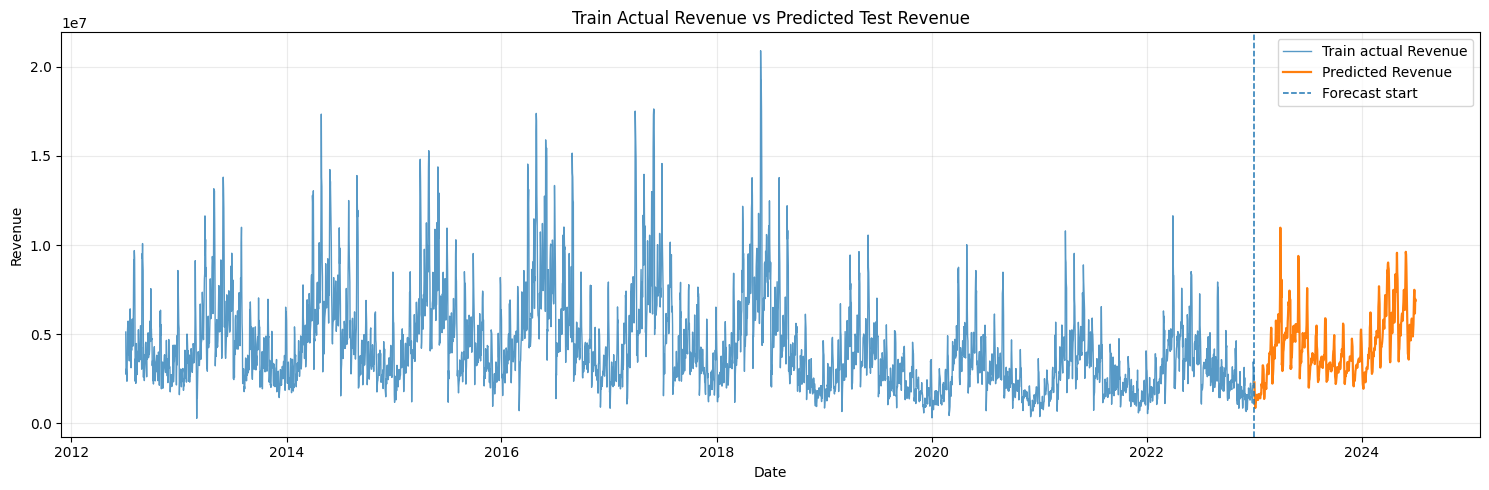

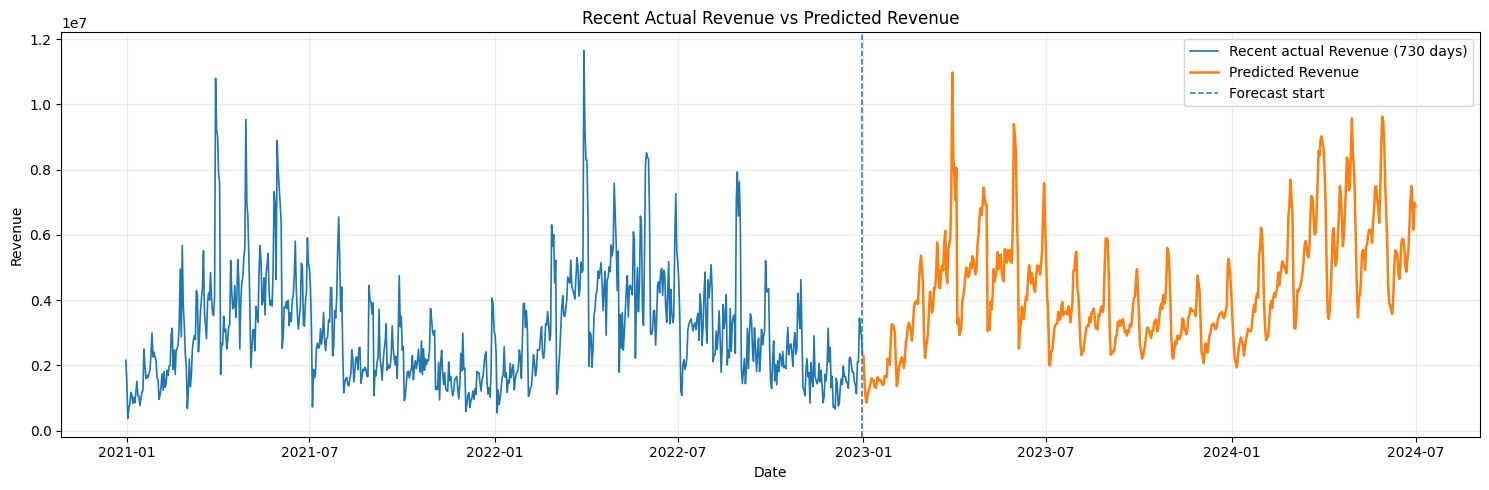

,month,forecast_revenue,forecast_cogs,forecast_gross_margin,avg_daily_revenue,peak_daily_revenue,forecast_margin_rate
0,2023-01,5.390338e+07,4.849685e+07,5.406526e+06,1.738819e+06,3.254524e+06,0.100300
1,2023-02,8.639040e+07,6.584502e+07,2.054538e+07,3.085372e+06,5.365529e+06,0.237820
2,2023-03,1.503109e+08,1.186443e+08,3.166656e+07,4.848737e+06,1.097543e+07,0.210674
3,2023-04,1.568992e+08,1.268387e+08,3.006050e+07,5.229973e+06,8.059450e+06,0.191591
4,2023-05,1.643824e+08,1.264391e+08,3.794336e+07,5.302659e+06,9.391564e+06,0.230824
5,2023-06,1.449093e+08,1.191881e+08,2.572127e+07,4.830311e+06,8.542300e+06,0.177499
6,2023-07,1.128426e+08,9.982426e+07,1.301829e+07,3.640082e+06,5.483434e+06,0.115367
7,2023-08,1.125118e+08,9.467958e+07,1.783223e+07,3.629413e+06,5.894208e+06,0.158492
8,2023-09,9.968779e+07,8.104005e+07,1.864774e+07,3.322926e+06,4.949552e+06,0.187061
9,2023-10,1.060678e+08,7.969408e+07,2.637368e+07,3.421541e+06,5.596398e+06,0.248649


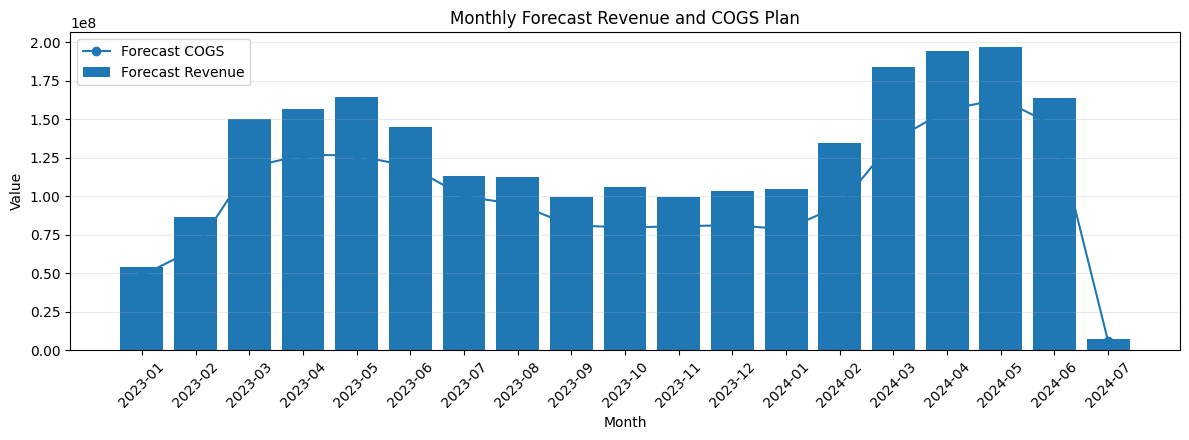

In [44]:
# ============================================================
# 16. FINAL SUBMISSION EXPORT + TRAIN VS PREDICTED VISUALIZATION
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", Path.cwd() / "outputs"))
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_SUBMISSION_COLS = ["Date", "Revenue", "COGS"]


def _as_datetime_date(df: pd.DataFrame, date_col: str = "Date") -> pd.DataFrame:
    """Return a copy with a normalized datetime Date column."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out


def _find_optional_file(filename: str):
    """Find optional files such as sample_submission.csv across common notebook environments."""
    candidates = []
    for key in ["DATA_DIR", "BASE_DIR"]:
        if key in globals():
            candidates.append(Path(globals()[key]) / filename)
    candidates += [
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path("/content") / filename,
        Path("/mnt/data") / filename,
    ]
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))
    for path in candidates:
        if path.exists():
            return path
    return None


def _build_required_test_dates() -> pd.DataFrame:
    """Use sample_submission/test_frame if available; otherwise build the official date range."""
    sample_path = _find_optional_file("sample_submission.csv")
    if sample_path is not None:
        sample = pd.read_csv(sample_path)
        if "Date" not in sample.columns:
            raise ValueError(f"sample_submission.csv found at {sample_path}, but it has no Date column.")
        return _as_datetime_date(sample[["Date"]])

    if "test_frame" in globals() and isinstance(test_frame, pd.DataFrame) and "Date" in test_frame.columns:
        print("Using test_frame order from notebook memory.")
        return _as_datetime_date(test_frame[["Date"]])

    test_start = globals().get("TEST_START", "2023-01-01")
    test_end = globals().get("TEST_END", "2024-07-01")
    print(f"sample_submission/test_frame not found. Building official date range: {test_start} to {test_end}.")
    return pd.DataFrame({"Date": pd.date_range(test_start, test_end, freq="D")})


def _seasonal_naive_fallback(train_sales: pd.DataFrame, future_dates: pd.Series) -> pd.DataFrame:
    """Robust fallback forecast using same day last year, then 2-year lag, then recent median."""
    hist = _as_datetime_date(train_sales)
    hist = hist.sort_values("Date")
    lookup = hist.set_index("Date")
    rows = []
    recent_median = hist.tail(min(365, len(hist)))[["Revenue", "COGS"]].median()

    for date in pd.to_datetime(future_dates):
        row = {"Date": date}
        for target in ["Revenue", "COGS"]:
            value = np.nan
            for lag_days in [365, 364, 366, 730, 728, 732]:
                lag_date = date - pd.Timedelta(days=lag_days)
                if lag_date in lookup.index and pd.notna(lookup.loc[lag_date, target]):
                    value = float(lookup.loc[lag_date, target])
                    break
            if pd.isna(value):
                value = float(recent_median[target])
            row[target] = max(value, 0.0)
        rows.append(row)
    return pd.DataFrame(rows)


def _get_or_build_final_submission() -> pd.DataFrame:
    """Return final submission with Date, Revenue, COGS in required order."""
    required_dates = _build_required_test_dates()

    # Case 1: previous final model cell has already created `submission`.
    if "submission" in globals() and isinstance(submission, pd.DataFrame):
        if set(REQUIRED_SUBMISSION_COLS).issubset(submission.columns):
            print("Using existing `submission` dataframe from final model cell.")
            pred = _as_datetime_date(submission[REQUIRED_SUBMISSION_COLS])
        else:
            pred = None
    else:
        pred = None

    # Case 2: previous cell created `forecast` only.
    if pred is None and "forecast" in globals() and isinstance(forecast, pd.DataFrame):
        if set(REQUIRED_SUBMISSION_COLS).issubset(forecast.columns):
            print("Using existing `forecast` dataframe from notebook memory.")
            pred = _as_datetime_date(forecast[REQUIRED_SUBMISSION_COLS])

    # Case 3: rebuild from trained final models if all needed objects exist.
    needed_for_model_rebuild = ["final_models", "base_features", "sales", "FEATURE_COLS", "recursive_predict"]
    if pred is None and all(name in globals() for name in needed_for_model_rebuild):
        try:
            print("Rebuilding predictions from final_models using recursive_predict().")
            pred = recursive_predict(final_models, base_features, sales, required_dates["Date"], FEATURE_COLS)
            pred = _as_datetime_date(pred[REQUIRED_SUBMISSION_COLS])
        except Exception as exc:
            print(f"Model rebuild failed, falling back to seasonal naive. Reason: {exc}")
            pred = None

    # Case 4: last-resort fallback so the notebook can still export a valid-format file.
    if pred is None:
        if "sales" not in globals() or not isinstance(sales, pd.DataFrame):
            raise RuntimeError("Cannot create submission: no `submission`, `forecast`, final model objects, or `sales` dataframe found.")
        print("Using seasonal-naive fallback forecast. Use this only as a safety baseline, not as the final leaderboard model.")
        pred = _seasonal_naive_fallback(sales, required_dates["Date"])

    # Preserve sample/test order exactly by left-joining predictions onto required_dates.
    final_sub = required_dates.merge(pred, on="Date", how="left")

    # Fill rare missing values using fallback, then enforce valid numeric output.
    if final_sub[["Revenue", "COGS"]].isna().any().any():
        if "sales" not in globals():
            raise ValueError("Missing prediction values and no sales dataframe available for fallback filling.")
        missing_dates = final_sub.loc[final_sub[["Revenue", "COGS"]].isna().any(axis=1), "Date"]
        fallback = _seasonal_naive_fallback(sales, missing_dates)
        final_sub = final_sub.drop(columns=["Revenue", "COGS"]).merge(
            pred.dropna(subset=["Revenue", "COGS"]), on="Date", how="left"
        )
        fill_block = required_dates.merge(fallback, on="Date", how="left")
        for target in ["Revenue", "COGS"]:
            final_sub[target] = final_sub[target].fillna(fill_block[target])

    for target in ["Revenue", "COGS"]:
        final_sub[target] = pd.to_numeric(final_sub[target], errors="coerce").fillna(0).clip(lower=0)

    return final_sub[REQUIRED_SUBMISSION_COLS]


# Build and export final files.
final_submission = _get_or_build_final_submission()

# Kaggle format: Date string + Revenue + COGS.
kaggle_submission = final_submission.copy()
kaggle_submission["Date"] = pd.to_datetime(kaggle_submission["Date"]).dt.strftime("%Y-%m-%d")
submission_path = OUTPUT_DIR / "submission.csv"
kaggle_submission.to_csv(submission_path, index=False)

# Richer internal forecast file for report/explanation.
forecast_metadata = final_submission.copy()
forecast_metadata["gross_margin"] = forecast_metadata["Revenue"] - forecast_metadata["COGS"]
forecast_metadata["gross_margin_rate"] = np.where(
    forecast_metadata["Revenue"] > 0,
    forecast_metadata["gross_margin"] / forecast_metadata["Revenue"],
    np.nan,
)
forecast_metadata["month"] = pd.to_datetime(forecast_metadata["Date"]).dt.to_period("M").astype(str)
forecast_metadata_path = OUTPUT_DIR / "final_forecast_with_metadata.csv"
forecast_metadata.to_csv(forecast_metadata_path, index=False)

display(kaggle_submission.head())
display(kaggle_submission.tail())

# Basic validation checks.
assert list(kaggle_submission.columns) == REQUIRED_SUBMISSION_COLS, "Submission columns must be Date, Revenue, COGS."
assert kaggle_submission["Date"].is_monotonic_increasing or _find_optional_file("sample_submission.csv") is not None, (
    "Dates are not sorted. This is okay only if preserving sample_submission order."
)
assert kaggle_submission[["Revenue", "COGS"]].notna().all().all(), "Submission contains missing Revenue/COGS."
assert (kaggle_submission[["Revenue", "COGS"]] >= 0).all().all(), "Submission contains negative Revenue/COGS."
print("Submission validation passed.")

# ----------------------------
# Visualization 1: full training history + predicted test period
# ----------------------------
train_sales = _as_datetime_date(sales[["Date", "Revenue", "COGS"]]).sort_values("Date")
plot_pred = final_submission.copy().sort_values("Date")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_sales["Date"], train_sales["Revenue"], label="Train actual Revenue", linewidth=1.0, alpha=0.75)
ax.plot(plot_pred["Date"], plot_pred["Revenue"], label="Predicted Revenue", linewidth=1.6)
ax.axvline(train_sales["Date"].max(), linestyle="--", linewidth=1.1, label="Forecast start")
ax.set_title("Train Actual Revenue vs Predicted Test Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig_path_1 = FIG_DIR / "train_actual_vs_predicted_revenue.png"
plt.savefig(fig_path_1, dpi=160, bbox_inches="tight")
plt.show()

# ----------------------------
# Visualization 2: recent training window + predicted period for easier readability
# ----------------------------
recent_days = 730
recent_train = train_sales[train_sales["Date"] >= train_sales["Date"].max() - pd.Timedelta(days=recent_days)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(recent_train["Date"], recent_train["Revenue"], label=f"Recent actual Revenue ({recent_days} days)", linewidth=1.2)
ax.plot(plot_pred["Date"], plot_pred["Revenue"], label="Predicted Revenue", linewidth=1.8)
ax.axvline(train_sales["Date"].max(), linestyle="--", linewidth=1.1, label="Forecast start")
ax.set_title("Recent Actual Revenue vs Predicted Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig_path_2 = FIG_DIR / "recent_actual_vs_predicted_revenue.png"
plt.savefig(fig_path_2, dpi=160, bbox_inches="tight")
plt.show()

# ----------------------------
# Visualization 3: monthly predicted revenue and COGS plan
# ----------------------------
monthly_forecast = forecast_metadata.groupby("month", as_index=False).agg(
    forecast_revenue=("Revenue", "sum"),
    forecast_cogs=("COGS", "sum"),
    forecast_gross_margin=("gross_margin", "sum"),
    avg_daily_revenue=("Revenue", "mean"),
    peak_daily_revenue=("Revenue", "max"),
)
monthly_forecast["forecast_margin_rate"] = monthly_forecast["forecast_gross_margin"] / monthly_forecast["forecast_revenue"].replace(0, np.nan)
monthly_forecast_path = OUTPUT_DIR / "monthly_forecast_summary.csv"
monthly_forecast.to_csv(monthly_forecast_path, index=False)

display(monthly_forecast)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(monthly_forecast["month"], monthly_forecast["forecast_revenue"], label="Forecast Revenue")
ax.plot(monthly_forecast["month"], monthly_forecast["forecast_cogs"], marker="o", label="Forecast COGS")
ax.set_title("Monthly Forecast Revenue and COGS Plan")
ax.set_xlabel("Month")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
fig_path_3 = FIG_DIR / "monthly_forecast_revenue_cogs.png"
plt.savefig(fig_path_3, dpi=160, bbox_inches="tight")
plt.show()
